# Parity Classification

Trains the three local architectures (Local-Hom, FittedHet-LogNorm, FittedHet-LogUniform) on two simplified SHD classification tasks:

- **2-class:** Odd digit vs Even digit (all 20 SHD classes remapped)
- **4-class:** Even-English / Odd-English / Even-German / Odd-German

For each of the six resulting models, the notebook:
1. Trains from scratch with the same 32-neuron / dt=1ms / bs=256 / lr=4e-3 / 25-epoch setup as FittedHet.
2. Saves a checkpoint to `Checkpoints/Parity/`.
3. Evaluates final test accuracy.
4. Computes Gaussian $\mathcal{M}$-information on one fixed subset of 16 evenly-spaced hidden neurons.

**Label remapping:**
- SHD classes 0 E = English digits 0 E; classes 10 E9 = German digits 0 E.
- Even: classes with even index (0,2,4,…,18); Odd: classes with odd index (1,3,5,…,19).
- 4-class mapping: Even-English=0, Odd-English=1, Even-German=2, Odd-German=3.

All three `tau` distributions (shared scalar / Gamma+LogNormal / Gamma+LogUniform) match FittedHet exactly.

In [1]:
from __future__ import annotations

import io
import sys
import json
import time
import random
from contextlib import contextmanager, redirect_stdout
from pathlib import Path
import importlib

import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import norm, rankdata, gamma as scipy_gamma, lognorm

import torch

PROJECT_ROOT      = Path(r"C:\Users\Priya\Desktop\research project (SNN Info Theory)")
WIMFO_ROOT        = PROJECT_ROOT / "wimfo"
PAPER_ROOT        = PROJECT_ROOT / "neural_heterogeneity" / "SuGD_code"
CHECKPOINT_DIR    = PROJECT_ROOT / "Project Files" / "Checkpoints" / "Parity"
TAU_ARTIFACT_PATH = PROJECT_ROOT / "Tau from 15 epoch run.json"
SHD_TRAIN         = PROJECT_ROOT / "data" / "shd" / "shd_train.h5"
SHD_TEST          = PROJECT_ROOT / "data" / "shd" / "shd_test.h5"

for extra_path in [WIMFO_ROOT, PAPER_ROOT]:
    if str(extra_path) not in sys.path:
        sys.path.insert(0, str(extra_path))

from clipper import ZeroOneClipper
from wimfo.W_M_Info import W_M_calculator
from wimfo.utils.utils_gauss import get_cov
from data_gen import open_file, sparse_data_generator
from reg_loss import loss as repo_loss
from SuSpike import SuSpike

RSNN    = importlib.import_module("model").RSNN
clipper = ZeroOneClipper()
DEVICE  = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Device           : {DEVICE}")
print(f"Train file       : {SHD_TRAIN.exists()}")
print(f"Test file        : {SHD_TEST.exists()}")
print(f"Tau artifact     : {TAU_ARTIFACT_PATH.exists()}")
print(f"Checkpoint dir   : {CHECKPOINT_DIR}")

Device           : cuda
Train file       : True
Test file        : True
Tau artifact     : True
Checkpoint dir   : C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Checkpoints\Parity


In [2]:
# ── Utility helpers ──────────────────────────────────────────────────────────

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def tau_ms_to_decay(tau_ms, time_step):
    tau_s = np.asarray(tau_ms, dtype=np.float64) * 1e-3
    tau_s = np.clip(tau_s, time_step * 1.001, None)
    return np.exp(-time_step / tau_s)


def decay_to_tau(decay, time_step):
    decay = np.clip(np.asarray(decay, dtype=np.float64), 1e-9, 1 - 1e-9)
    return -time_step / np.log(decay)


def summarize_hidden_taus(model, time_step: float):
    hl    = model.network[0]
    alpha = hl.alpha.detach().cpu().numpy().ravel()
    beta  = hl.beta.detach().cpu().numpy().ravel()
    return {
        "alpha_unique":    int(np.unique(np.round(alpha, 8)).size),
        "beta_unique":     int(np.unique(np.round(beta,  8)).size),
        "tau_syn_ms_min":  float(decay_to_tau(alpha, time_step).min() * 1e3),
        "tau_syn_ms_max":  float(decay_to_tau(alpha, time_step).max() * 1e3),
        "tau_mem_ms_min":  float(decay_to_tau(beta,  time_step).min() * 1e3),
        "tau_mem_ms_max":  float(decay_to_tau(beta,  time_step).max() * 1e3),
    }


def save_model_checkpoint(path, model, history, elapsed_s, prms, extra=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "model_state_dict": model.state_dict(),
        "history":          history,
        "elapsed_s":        float(elapsed_s),
        "prms":             {k: v for k, v in prms.items()
                             if not isinstance(v, (torch.dtype, torch.device))},
    }
    if extra:
        payload.update(extra)
    torch.save(payload, path)
    return path


# ── Data loading ─────────────────────────────────────────────────────────────

@contextmanager
def shd_open(path):
    units, times, labels = open_file(str(path))
    try:
        yield units, times, labels
    finally:
        units._v_file.close()


class SHDCache:
    """Pre-loads all SHD spike events into RAM lists; eliminates per-batch HDF5 I/O."""
    def __init__(self, path):
        raw_u, raw_t, raw_l = open_file(str(path))
        self.units  = list(raw_u[:])
        self.times  = list(raw_t[:])
        self.labels = np.array(raw_l[:])
        raw_u._v_file.close()
        print(f"  SHDCache: {len(self.labels)} samples from {Path(str(path)).name}")


def _is_cache(obj):
    return hasattr(obj, "units") and hasattr(obj, "times") and hasattr(obj, "labels")


@contextmanager
def shd_open_cached(cache):
    yield cache.units, cache.times, cache.labels


# ── Batch generator with task_label_map support ───────────────────────────────

def fast_sparse_data_generator(units, times, labels, prms,
                                shuffle=True, epoch=0, drop_last=True):
    """Vectorised sparse batch generator. Reads task_label_map from prms when present.

    task_label_map: dict mapping original SHD class index ↁEtask class index.
    When None, falls back to class_list.index() (standard 20-class behaviour).
    """
    rate  = prms.get("rate",  0.0)
    p_del = prms.get("p_del", 0.0)
    if rate != 0.0 or p_del != 0.0:
        yield from sparse_data_generator(units, times, labels, prms,
                                         shuffle=shuffle, epoch=epoch,
                                         drop_last=drop_last)
        return

    seed           = prms["seed"] + epoch
    batch_size     = prms["batch_size"]
    nb_steps       = prms["nb_steps"]
    nb_units       = prms["nb_inputs"]
    inv_dt         = 1.0 / prms["time_step"]
    class_list     = prms["class_list"]
    task_label_map = prms.get("task_label_map", None)

    label_arr    = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
    sample_index = np.where(np.isin(label_arr, class_list))[0]
    num_samples  = len(sample_index)
    n_batches    = (num_samples // batch_size) if drop_last else -(-num_samples // batch_size)

    np.random.seed(seed)
    if shuffle:
        np.random.shuffle(sample_index)

    for counter in range(n_batches):
        batch_index = sample_index[batch_size * counter :
                                   min(num_samples, batch_size * (counter + 1))]
        actual_bs   = len(batch_index)
        t_arrays    = [np.round(times[idx] * inv_dt).astype(np.int64) for idx in batch_index]
        u_arrays    = [units[idx] for idx in batch_index]
        lengths     = np.array([len(a) for a in t_arrays], dtype=np.int64)

        if lengths.sum():
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), lengths)
            valid  = all_ts < nb_steps
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            i = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            v = torch.ones(all_ts.size, dtype=torch.float32)
            X_batch = torch.sparse_coo_tensor(
                i, v, torch.Size([actual_bs, nb_steps, nb_units])
            ).to_dense()
        else:
            X_batch = torch.zeros(actual_bs, nb_steps, nb_units)

        X_batch.clamp_(max=1.0)

        if task_label_map is not None:
            y_batch = torch.tensor(
                [task_label_map[int(a)] for a in label_arr[batch_index]],
                dtype=torch.long,
            )
        else:
            y_batch = torch.tensor(
                [class_list.index(int(a)) for a in label_arr[batch_index]],
                dtype=torch.long,
            )
        yield X_batch, y_batch


def shd_generator(units, times, labels, prms, shuffle, epoch, drop_last):
    yield from fast_sparse_data_generator(
        units, times, labels, prms,
        shuffle=shuffle, epoch=epoch, drop_last=drop_last,
    )


# ── Training helpers ─────────────────────────────────────────────────────────

def count_epoch_samples(sample_count, batch_size, drop_last):
    if drop_last:
        return (sample_count // batch_size) * batch_size
    return sample_count


def forward_logits(model, x):
    layer_recs  = model(0, 0, x)
    output_layer = layer_recs[-1]
    logits, _   = torch.max(output_layer[1], dim=1)
    return logits, layer_recs


def make_optimizer(model, prms):
    """Separate Adam groups for weight params and alpha/beta (tau) params.
    Works for Local-Hom (trainable scalar ab) and FittedHet (frozen ab).
    """
    weight_params, ab_params = [], []
    for name, param in model.named_parameters():
        if not param.requires_grad:
            continue
        if "alpha" in name or "beta" in name:
            ab_params.append(param)
        else:
            weight_params.append(param)
    param_groups = [{"params": weight_params,
                     "lr": prms["lr"],
                     "weight_decay": prms["weight_decay"]}]
    if ab_params:
        param_groups.append({"params": ab_params, "lr": prms["lr_ab"]})
    return torch.optim.Adam(param_groups, betas=tuple(prms["betas"]))


@torch.no_grad()
def evaluate_batches(model, prms, units, times, labels,
                     num_samples=None, use_amp=True):
    if num_samples is None:
        total = int(np.isin(labels[:], prms["class_list"]).sum())
        num_samples = count_epoch_samples(total, prms["batch_size"], drop_last=False)
    _amp = use_amp and DEVICE.type == "cuda"
    model.eval()
    loss_acc, correct = 0.0, 0
    for x, y in shd_generator(units, times, labels, prms,
                               shuffle=False, epoch=0, drop_last=False):
        x, y = x.to(DEVICE), y.to(DEVICE)
        with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=_amp):
            logits, layer_recs = forward_logits(model, x)
            loss_acc += repo_loss(logits, layer_recs, y, num_samples, prms).item()
        correct += (logits.argmax(1) == y).sum().item()
    return {"loss": loss_acc, "acc": correct / max(num_samples, 1), "n": num_samples}


def train_experiment(model, prms, train_data, test_data, use_amp=True):
    """train_data / test_data: Path or SHDCache."""
    _amp    = use_amp and DEVICE.type == "cuda"
    scaler  = torch.amp.GradScaler("cuda", enabled=_amp)
    opt     = make_optimizer(model, prms)
    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}

    tr_ctx = shd_open_cached if _is_cache(train_data) else shd_open
    te_ctx = shd_open_cached if _is_cache(test_data)  else shd_open

    with tr_ctx(train_data) as (u_tr, t_tr, l_tr), \
         te_ctx(test_data)  as (u_te, t_te, l_te):

        if not prms["class_list"]:
            prms["class_list"] = np.unique(l_tr[:]).tolist()

        total_tr = int(np.isin(l_tr[:], prms["class_list"]).sum())
        total_te = int(np.isin(l_te[:], prms["class_list"]).sum())
        eff_tr   = count_epoch_samples(total_tr, prms["batch_size"], drop_last=bool(prms["drop_last"]))
        eff_te   = count_epoch_samples(total_te, prms["batch_size"], drop_last=False)

        if prms["clip"]:
            model.apply(clipper)

        for epoch in range(1, prms["nb_epochs"] + 1):
            ep_t0 = time.perf_counter()
            model.train()
            ep_loss, ep_correct = 0.0, 0

            for x, y in shd_generator(u_tr, t_tr, l_tr, prms,
                                       shuffle=True, epoch=epoch,
                                       drop_last=prms["drop_last"]):
                x, y = x.to(DEVICE), y.to(DEVICE)
                opt.zero_grad()
                with torch.autocast(device_type=DEVICE.type, dtype=torch.float16, enabled=_amp):
                    logits, layer_recs = forward_logits(model, x)
                    loss_val = repo_loss(logits, layer_recs, y, eff_tr, prms)
                scaler.scale(loss_val).backward()
                scaler.step(opt)
                scaler.update()
                if prms["clip"]:
                    model.apply(clipper)
                ep_loss    += loss_val.item()
                ep_correct += (logits.argmax(1) == y).sum().item()

            test_m = evaluate_batches(model, prms, u_te, t_te, l_te,
                                      num_samples=eff_te, use_amp=use_amp)
            history["train_loss"].append(ep_loss)
            history["train_acc"].append(ep_correct / max(eff_tr, 1))
            history["test_loss"].append(test_m["loss"])
            history["test_acc"].append(test_m["acc"])
            elapsed = time.perf_counter() - ep_t0
            print(f"  epoch={epoch:03d}  "
                  f"train_acc={ep_correct/max(eff_tr,1):.3f}  "
                  f"test_acc={test_m['acc']:.3f}  "
                  f"({elapsed/60:.1f} min)")

    return history


print("Helpers loaded.")

Helpers loaded.


In [3]:
# ── Load data caches ─────────────────────────────────────────────────────────
print("Pre-loading SHD training data into RAM...")
SHD_TRAIN_CACHE = SHDCache(SHD_TRAIN)
print("Pre-loading SHD test data into RAM...")
SHD_TEST_CACHE = SHDCache(SHD_TEST)

# ── Load tau distributions from the 15-epoch Local-Het artifact ──────────────
# Fits Gamma (tau_syn) and Log-Normal / Log-Uniform (tau_mem) to the learned
# per-neuron time constants from the Local-Het checkpoint run.
with open(TAU_ARTIFACT_PATH, "r", encoding="utf-8") as fh:
    tau_artifact = json.load(fh)

artifact_syn_ms = np.asarray(tau_artifact["heterogeneous"]["tau_syn_ms"], dtype=np.float64)
artifact_mem_ms = np.asarray(tau_artifact["heterogeneous"]["tau_mem_ms"], dtype=np.float64)

# Gamma fit to tau_syn
syn_shape, _, syn_scale = scipy_gamma.fit(artifact_syn_ms, floc=0.0)
artifact_syn_bounds = (float(artifact_syn_ms.min()), float(artifact_syn_ms.max()))

# Log-Normal fit to tau_mem
mem_lognorm_shape, _, mem_lognorm_scale = lognorm.fit(artifact_mem_ms, floc=0.0)
artifact_mem_bounds = (float(artifact_mem_ms.min()), float(artifact_mem_ms.max()))


def sample_gamma_syn_ms(size, rng):
    vals = scipy_gamma.rvs(syn_shape, loc=0.0, scale=syn_scale,
                           size=size, random_state=rng)
    return np.clip(vals, artifact_syn_bounds[0], artifact_syn_bounds[1])


def sample_lognormal_mem_ms(size, rng):
    vals = lognorm.rvs(mem_lognorm_shape, loc=0.0, scale=mem_lognorm_scale,
                       size=size, random_state=rng)
    return np.clip(vals, artifact_mem_bounds[0], artifact_mem_bounds[1])


def sample_loguniform_mem_ms(size, rng):
    low, high = artifact_mem_bounds
    return np.exp(rng.uniform(np.log(low), np.log(high), size=size))


# ── Results accumulator (populated by each training cell) ────────────────────
all_results = {}

print(f"\nGamma syn: shape={syn_shape:.4f}  scale={syn_scale:.4f}  "
      f"bounds={artifact_syn_bounds[0]:.1f}–{artifact_syn_bounds[1]:.1f} ms")
print(f"LogNorm mem: shape={mem_lognorm_shape:.4f}  scale={mem_lognorm_scale:.4f}  "
      f"bounds={artifact_mem_bounds[0]:.1f}–{artifact_mem_bounds[1]:.1f} ms")
print(f"LogUniform mem: bounds={artifact_mem_bounds[0]:.1f}–{artifact_mem_bounds[1]:.1f} ms")

Pre-loading SHD training data into RAM...
  SHDCache: 8156 samples from shd_train.h5
Pre-loading SHD test data into RAM...
  SHDCache: 2264 samples from shd_test.h5

Gamma syn: shape=1.0304  scale=22.7390  bounds=2.0 E9.7 ms
LogNorm mem: shape=0.9888  scale=25.4979  bounds=2.1 E9.7 ms
LogUniform mem: bounds=2.1 E9.7 ms


In [4]:
# ── Shared architecture base (matches FittedHet / Local Network Test) ─────────
BASE_PRMS = {
    "seed":         1000,
    "dtype":        torch.float,
    "device":       DEVICE,
    "cuda":         DEVICE.type == "cuda",
    "nb_inputs":    700,
    "nb_hidden":    [],
    "nb_recurrent": 32,
    "nb_outputs":   20,    # overridden per task
    "batch_size":   256,
    "time_step":    1.0e-3,
    "nb_steps":     1000,
    "tau_syn":      10e-3,
    "tau_mem":      20e-3,
    "threshold":    1.0,
    "tref":         0.0,
    "dist":         "gamma",
    "dist_prms":    3.0,
    "lr":           4e-3,
    "lr_ab":        4e-3,
    "betas":        (0.9, 0.999),
    "weight_decay": 0.0,
    "nb_epochs":    25,
    "drop_last":    True,
    "sl": 0.0, "thetal": 0.0, "su": 0.0, "thetau": 0.0,
    "rate": 0.0,  "p_del": 0.0,
    "train_th": 0, "het_th": 0,
    "train_reset": 0, "het_reset": 0,
    "train_rest": 0,  "het_rest": 0,
    "sparse_data_generator": "sparse_data_generator",
    "time_scale": [0.5, 1.0],
    "model":      "RSNN",
    "savestep":   10,
    "clip":       1,
    "plot_step":  50,
    "class_list": list(range(20)),  # all 20 SHD classes  Eremapping done via task_label_map
    "task_label_map": None,          # overridden per task
    "het_ab":      1,
    "train_ab":    0,
    "train_hom_ab": 0,
}

# ── Task definitions ──────────────────────────────────────────────────────────

def make_2class_task():
    """Even SHD digit indices (0,2,4,...,18) ↁEclass 0; Odd ↁEclass 1."""
    return {
        "nb_outputs":     2,
        "task_label_map": {i: i % 2 for i in range(20)},
        "class_list":     list(range(20)),
    }


def make_4class_task():
    """
    Even-English  (0,2,4,6,8)         ↁEclass 0
    Odd-English   (1,3,5,7,9)         ↁEclass 1
    Even-German   (10,12,14,16,18)    ↁEclass 2
    Odd-German    (11,13,15,17,19)    ↁEclass 3
    Formula: is_german*2 + is_odd
    """
    label_map = {}
    for i in range(20):
        is_german   = int(i >= 10)
        is_odd      = int(i % 2 == 1)
        label_map[i] = is_german * 2 + is_odd
    return {
        "nb_outputs":     4,
        "task_label_map": label_map,
        "class_list":     list(range(20)),
    }


TASK_2CLASS = make_2class_task()
TASK_4CLASS = make_4class_task()

# ── Model factory functions ───────────────────────────────────────────────────

def _base_prms_for_task(task_override, seed=1000):
    prms = dict(BASE_PRMS)
    prms.update(task_override)
    prms.update({"seed": seed, "dtype": torch.float,
                 "device": DEVICE, "cuda": DEVICE.type == "cuda"})
    prms["alpha"] = float(np.exp(-prms["time_step"] / prms["tau_syn"]))
    prms["beta"]  = float(np.exp(-prms["time_step"] / prms["tau_mem"]))
    return prms


def build_local_hom_model(task_override, seed=1000):
    """32-neuron RSNN with one shared learnable alpha/beta (train_hom_ab=1)."""
    prms = _base_prms_for_task(task_override, seed=seed)
    prms.update({"het_ab": 0, "train_ab": 0, "train_hom_ab": 1})
    set_seed(seed)
    model = RSNN(prms, rec=True).to(DEVICE)
    return model, prms


def build_fitted_het_model(task_override, syn_sampler, mem_sampler, seed):
    """32-neuron RSNN with per-neuron fixed alpha/beta sampled from fitted distributions."""
    prms = _base_prms_for_task(task_override, seed=seed)
    prms.update({"het_ab": 1, "train_ab": 0, "train_hom_ab": 0})
    set_seed(seed)
    model = RSNN(prms, rec=True).to(DEVICE)

    hidden_size = int(model.network[0].output_size)
    rng         = np.random.default_rng(seed)
    tau_syn_ms  = np.asarray(syn_sampler(hidden_size, rng), dtype=np.float64)
    tau_mem_ms  = np.asarray(mem_sampler(hidden_size, rng), dtype=np.float64)

    alpha_init = tau_ms_to_decay(tau_syn_ms, prms["time_step"]).reshape(1, -1)
    beta_init  = tau_ms_to_decay(tau_mem_ms, prms["time_step"]).reshape(1, -1)

    with torch.no_grad():
        hl = model.network[0]
        hl.alpha.copy_(torch.tensor(alpha_init, device=DEVICE, dtype=prms["dtype"]))
        hl.beta.copy_( torch.tensor(beta_init,  device=DEVICE, dtype=prms["dtype"]))
        hl.alpha.requires_grad_(False)
        hl.beta.requires_grad_(False)

    return model, prms, tau_syn_ms, tau_mem_ms


print("Task definitions and model factories ready.")
print(f"  2-class label map (sample): { {k: TASK_2CLASS['task_label_map'][k] for k in [0,1,10,11]} }")
print(f"  4-class label map (sample): { {k: TASK_4CLASS['task_label_map'][k] for k in [0,1,10,11]} }")

Task definitions and model factories ready.
  2-class label map (sample): {0: 0, 1: 1, 10: 0, 11: 1}
  4-class label map (sample): {0: 0, 1: 1, 10: 2, 11: 3}


In [17]:
# ── M-information helpers  Esweep over [2, 4, 8, 16, 32] neuron subsets ───────
# Collects all 32 hidden membrane trajectories once per model, then slices
# evenly-spaced subsets of each requested size. Uses option='data' first
# (passes Gaussian-copula-normalised data directly to wimfo) and falls
# back to progressively-regularised covariance solves when needed.

M_INFO_SUBSET_SIZES = [2, 4, 8, 16, 32]

print(f"M-info subset sizes: {M_INFO_SUBSET_SIZES}")


def _gaussian_copula_normalize(data: np.ndarray) -> np.ndarray:
    transformed = np.zeros_like(data, dtype=np.float64)
    for idx, row in enumerate(data):
        if np.allclose(row, row[0]):
            continue
        ranks = rankdata(row, method="average")
        uniform = np.clip((ranks - 0.5) / len(row), 1e-6, 1.0 - 1e-6)
        transformed[idx] = norm.ppf(uniform)
    return transformed


def _inject_small_jitter(data: np.ndarray, eps: float = 1e-6) -> np.ndarray:
    """Break exactly-constant rows to avoid degenerate covariances."""
    row_std = np.nanstd(data, axis=1)
    deg_idx = np.flatnonzero(row_std <= 1e-12)
    if deg_idx.size == 0:
        return data

    base = np.linspace(-1.0, 1.0, data.shape[1], dtype=np.float64)
    for offset, ridx in enumerate(deg_idx, start=1):
        data[ridx] = (eps * offset) * base
    return data


def _compute_wm_from_matrix(hidden_data, lag=1, ridge=1e-2):
    """Run W/M calculation with robust fallbacks for high-dimensional subsets."""
    gaussian_data = _gaussian_copula_normalize(hidden_data)
    gaussian_data = np.nan_to_num(gaussian_data, nan=0.0, posinf=0.0, neginf=0.0)
    gaussian_data = _inject_small_jitter(gaussian_data)

    opt_order = [
        ("Adam", {"atol": 1e-3, "rtol": 1e-3, "max_iter": 30000}),
        ("Adam", {"atol": 5e-3, "rtol": 5e-3, "max_iter": 60000}),
        ("Newton", None),
    ]

    lag0 = max(int(lag), 1)
    lag_candidates = sorted(set([lag0, lag0 * 2, lag0 * 4]))
    stride_candidates = [1, 2, 4]

    # Primary path: pass Gaussian data directly.
    for stride in stride_candidates:
        data_view = gaussian_data[:, ::stride]
        if data_view.shape[1] <= max(8, 2 * data_view.shape[0] + 2):
            continue
        for lag_try in lag_candidates:
            for optimiser, options in opt_order:
                try:
                    with io.StringIO() as buf, redirect_stdout(buf):
                        w_bits, m_bits = W_M_calculator(
                            data_view,
                            t=lag_try,
                            option="data",
                            type="gaussian",
                            unit="bits",
                            verbose=False,
                            optimiser=optimiser,
                            options=options,
                        )
                except Exception:
                    continue
                if np.isfinite(w_bits) and np.isfinite(m_bits):
                    return {
                        "W_bits": float(w_bits),
                        "M_bits": float(m_bits),
                        "samples": int(data_view.shape[1]),
                        "optimiser": f"{optimiser}(data)",
                        "lag": int(lag_try),
                        "stride": int(stride),
                    }

    # Fallback: explicit ridge-regularised lagged covariance.
    ridge_candidates = sorted(set([float(ridge), 5.0 * float(ridge), 1e-1, 2e-1, 5e-1, 1.0]))
    last_error = None

    for stride in stride_candidates:
        data_view = gaussian_data[:, ::stride]
        if data_view.shape[1] <= max(8, 2 * data_view.shape[0] + 2):
            continue

        for lag_try in lag_candidates:
            try:
                cov = np.asarray(get_cov(data_view, t=lag_try), dtype=np.float64)
            except Exception as exc:
                last_error = exc
                continue

            cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
            cov = 0.5 * (cov + cov.T)
            scale = np.trace(cov) / max(cov.shape[0], 1)
            if not np.isfinite(scale) or scale <= 0.0:
                scale = 1.0
            eye = np.eye(cov.shape[0], dtype=np.float64)

            for ridge_try in ridge_candidates:
                lagged_cov = cov + ridge_try * scale * eye
                try:
                    eigvals, eigvecs = np.linalg.eigh(lagged_cov)
                    min_eval = max(scale * 1e-8, 1e-10)
                    eigvals = np.clip(eigvals, min_eval, None)
                    lagged_cov = (eigvecs * eigvals[np.newaxis, :]) @ eigvecs.T
                    lagged_cov = 0.5 * (lagged_cov + lagged_cov.T)
                except np.linalg.LinAlgError as exc:
                    last_error = exc
                    continue

                for optimiser, options in opt_order:
                    try:
                        with io.StringIO() as buf, redirect_stdout(buf):
                            w_bits, m_bits = W_M_calculator(
                                lagged_cov,
                                option="distr",
                                type="gaussian",
                                unit="bits",
                                verbose=False,
                                optimiser=optimiser,
                                options=options,
                            )
                    except Exception as exc:
                        last_error = exc
                        continue

                    if np.isfinite(w_bits) and np.isfinite(m_bits):
                        return {
                            "W_bits": float(w_bits),
                            "M_bits": float(m_bits),
                            "samples": int(data_view.shape[1]),
                            "optimiser": f"{optimiser}(distr,ridge={ridge_try:.3g})",
                            "lag": int(lag_try),
                            "stride": int(stride),
                        }

    if last_error is None:
        raise RuntimeError("W/M calculation failed for all optimiser/regularisation combinations.")
    raise RuntimeError(f"W/M calculation failed for all optimiser/regularisation combinations. Last error: {last_error}")


@torch.no_grad()
def collect_all_hidden(model, prms, data_source, max_batches=2, downsample_stride=4):
    """Collect ALL hidden membrane trajectories in one pass.
    Returns array of shape (nb_recurrent, n_timepoints).
    """
    stride = max(int(downsample_stride), 1)
    nb_hidden = int(model.network[0].output_size)
    chunks = []
    ctx = shd_open_cached if _is_cache(data_source) else shd_open
    with ctx(data_source) as (units, times, labels):
        for bidx, (x, _) in enumerate(
            shd_generator(units, times, labels, prms,
                          shuffle=False, epoch=0, drop_last=False)
        ):
            if bidx >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            # layer_recs[0][1]: [batch, nb_steps, nb_recurrent]
            mem = layer_recs[0][1][:, ::stride, :].detach().cpu().numpy()
            mem = np.transpose(mem, (2, 0, 1)).reshape(nb_hidden, -1)  # (nb_recurrent, batch*T')
            chunks.append(mem)
    if not chunks:
        raise RuntimeError("No batches collected for M-info.")
    return np.concatenate(chunks, axis=1)  # (nb_recurrent, N)


def compute_m_info_sweep(model, prms, data_source,
                         subset_sizes=None, max_batches=2,
                         lag=1, downsample_stride=4, ridge=1e-2):
    """Compute M-info for each subset size in subset_sizes (one hidden-data
    collection pass, then slice per subset size).

    Returns dict keyed by subset_size:
      {2: {"W_bits": ..., "M_bits": ..., "samples": ..., "optimiser": ...},
       4: {...}, ...}
    """
    if subset_sizes is None:
        subset_sizes = M_INFO_SUBSET_SIZES

    nb_hidden = int(model.network[0].output_size)
    all_hidden = collect_all_hidden(model, prms, data_source,
                                    max_batches=max_batches,
                                    downsample_stride=downsample_stride)
    results = {}
    for k in subset_sizes:
        k = int(k)
        idx = np.linspace(0, nb_hidden - 1, min(k, nb_hidden), dtype=int)
        try:
            r = _compute_wm_from_matrix(all_hidden[idx, :], lag=lag, ridge=ridge)
            r["subset_size"] = k
            r["indices"] = idx.tolist()
            results[k] = r
        except Exception as exc:
            results[k] = {"subset_size": k, "error": str(exc),
                          "W_bits": float("nan"), "M_bits": float("nan")}
    return results


print("M-info helpers loaded.")


M-info subset sizes: [2, 4, 8, 16, 32]
M-info helpers loaded.


## 2-Class: Odd vs Even

All 20 SHD classes are used. Labels are remapped: even-index digits (0,2,4,…,18) ↁEclass 0, odd-index digits (1,3,5,…,19) ↁEclass 1. Chance level = 50%.

Three architectures:
- **Local-Hom**: shared scalar α/β, learnable (`train_hom_ab=1`)
- **FittedHet-LogNorm**: per-neuron fixed ρEfrom Gamma(syn) + Log-Normal(mem)
- **FittedHet-LogUniform**: per-neuron fixed ρEfrom Gamma(syn) + Log-Uniform(mem)

In [6]:
required = ["TASK_2CLASS", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE", "all_results"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run setup cells first. Missing: {missing}")

# Local-Hom (2-class)  Eshared scalar alpha/beta, trainable
set_seed(1000)
model_2c_hom, prms_2c_hom = build_local_hom_model(TASK_2CLASS, seed=1000)

# FittedHet-LogNorm (2-class)  EGamma tau_syn, Log-Normal tau_mem, frozen
model_2c_ln, prms_2c_ln, tau_syn_2c_ln, tau_mem_2c_ln = build_fitted_het_model(
    TASK_2CLASS, sample_gamma_syn_ms, sample_lognormal_mem_ms, seed=1101
)

# FittedHet-LogUniform (2-class)  EGamma tau_syn, Log-Uniform tau_mem, frozen
model_2c_lu, prms_2c_lu, tau_syn_2c_lu, tau_mem_2c_lu = build_fitted_het_model(
    TASK_2CLASS, sample_gamma_syn_ms, sample_loguniform_mem_ms, seed=1202
)

print("2-class models built.")
for lbl, prms, tsyn, tmem in [
    ("Local-Hom",        prms_2c_hom, None,         None),
    ("FittedHet-LogNorm",  prms_2c_ln,  tau_syn_2c_ln, tau_mem_2c_ln),
    ("FittedHet-LogUnif",  prms_2c_lu,  tau_syn_2c_lu, tau_mem_2c_lu),
]:
    tau_str = (
        f"  tau_syn=[{tsyn.min():.1f},{tsyn.max():.1f}]ms  "
        f"tau_mem=[{tmem.min():.1f},{tmem.max():.1f}]ms"
    ) if tsyn is not None else ""
    print(f"  {lbl:22s}  nb_outputs={prms['nb_outputs']}{tau_str}")

2-class models built.
  Local-Hom               nb_outputs=2
  FittedHet-LogNorm       nb_outputs=2  tau_syn=[2.0,97.4]ms  tau_mem=[5.8,99.7]ms
  FittedHet-LogUnif       nb_outputs=2  tau_syn=[2.0,68.7]ms  tau_mem=[2.9,93.5]ms


In [7]:
# ── Train 2-class Local-Hom ───────────────────────────────────────────────────
required = ["model_2c_hom", "prms_2c_hom", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 2-class Local-Hom...")
t0 = time.perf_counter()
hist_2c_hom = train_experiment(model_2c_hom, prms_2c_hom, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed     = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "2class_local_hom.pt",
    model_2c_hom, hist_2c_hom, elapsed, prms_2c_hom,
    extra={"label": "2class_local_hom", "task": "binary_parity",
           "nb_outputs": prms_2c_hom["nb_outputs"]},
)
all_results["2class_local_hom"] = {
    "label": "Local-Hom", "task": "2-class", "arch": "local_hom",
    "history": hist_2c_hom,
    "final_test_acc": hist_2c_hom["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_2c_hom['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")

Training 2-class Local-Hom...
  epoch=001  train_acc=0.536  test_acc=0.561  (4.1 min)
  epoch=002  train_acc=0.637  test_acc=0.635  (3.9 min)
  epoch=003  train_acc=0.712  test_acc=0.771  (3.9 min)
  epoch=004  train_acc=0.759  test_acc=0.712  (4.6 min)
  epoch=005  train_acc=0.792  test_acc=0.736  (4.1 min)
  epoch=006  train_acc=0.806  test_acc=0.806  (4.3 min)
  epoch=007  train_acc=0.820  test_acc=0.756  (4.2 min)
  epoch=008  train_acc=0.828  test_acc=0.772  (4.5 min)
  epoch=009  train_acc=0.834  test_acc=0.765  (2.8 min)
  epoch=010  train_acc=0.849  test_acc=0.742  (2.4 min)
  epoch=011  train_acc=0.849  test_acc=0.753  (2.3 min)
  epoch=012  train_acc=0.864  test_acc=0.792  (2.2 min)
  epoch=013  train_acc=0.881  test_acc=0.793  (2.9 min)
  epoch=014  train_acc=0.887  test_acc=0.798  (3.7 min)
  epoch=015  train_acc=0.889  test_acc=0.829  (4.2 min)
  epoch=016  train_acc=0.907  test_acc=0.817  (3.5 min)
  epoch=017  train_acc=0.904  test_acc=0.731  (2.7 min)
  epoch=018  train

In [8]:
# ── Train 2-class FittedHet-LogNorm ───────────────────────────────────────────
required = ["model_2c_ln", "prms_2c_ln", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 2-class FittedHet-LogNorm...")
t0 = time.perf_counter()
hist_2c_ln = train_experiment(model_2c_ln, prms_2c_ln, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed    = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "2class_fittedhet_lognorm.pt",
    model_2c_ln, hist_2c_ln, elapsed, prms_2c_ln,
    extra={"label": "2class_fittedhet_lognorm", "task": "binary_parity",
           "nb_outputs": prms_2c_ln["nb_outputs"],
           "tau_syn_ms": tau_syn_2c_ln.tolist(),
           "tau_mem_ms": tau_mem_2c_ln.tolist(),
           "distribution_family": {"tau_syn": "gamma", "tau_mem": "lognormal"}},
)
all_results["2class_fittedhet_ln"] = {
    "label": "FittedHet-LogNorm", "task": "2-class", "arch": "fittedhet_lognorm",
    "history": hist_2c_ln,
    "final_test_acc": hist_2c_ln["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_2c_ln['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")

Training 2-class FittedHet-LogNorm...
  epoch=001  train_acc=0.502  test_acc=0.505  (2.4 min)
  epoch=002  train_acc=0.509  test_acc=0.507  (2.3 min)
  epoch=003  train_acc=0.518  test_acc=0.519  (2.4 min)
  epoch=004  train_acc=0.546  test_acc=0.554  (2.6 min)
  epoch=005  train_acc=0.571  test_acc=0.583  (2.8 min)
  epoch=006  train_acc=0.624  test_acc=0.641  (2.3 min)
  epoch=007  train_acc=0.724  test_acc=0.710  (2.1 min)
  epoch=008  train_acc=0.799  test_acc=0.814  (2.1 min)
  epoch=009  train_acc=0.827  test_acc=0.799  (2.1 min)
  epoch=010  train_acc=0.840  test_acc=0.847  (2.1 min)
  epoch=011  train_acc=0.868  test_acc=0.852  (2.1 min)
  epoch=012  train_acc=0.870  test_acc=0.854  (2.2 min)
  epoch=013  train_acc=0.886  test_acc=0.855  (2.1 min)
  epoch=014  train_acc=0.902  test_acc=0.852  (2.1 min)
  epoch=015  train_acc=0.913  test_acc=0.855  (2.1 min)
  epoch=016  train_acc=0.919  test_acc=0.871  (2.4 min)
  epoch=017  train_acc=0.926  test_acc=0.882  (3.4 min)
  epoch=01

In [9]:
# ── Train 2-class FittedHet-LogUniform ────────────────────────────────────────
required = ["model_2c_lu", "prms_2c_lu", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 2-class FittedHet-LogUniform...")
t0 = time.perf_counter()
hist_2c_lu = train_experiment(model_2c_lu, prms_2c_lu, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed    = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "2class_fittedhet_loguniform.pt",
    model_2c_lu, hist_2c_lu, elapsed, prms_2c_lu,
    extra={"label": "2class_fittedhet_loguniform", "task": "binary_parity",
           "nb_outputs": prms_2c_lu["nb_outputs"],
           "tau_syn_ms": tau_syn_2c_lu.tolist(),
           "tau_mem_ms": tau_mem_2c_lu.tolist(),
           "distribution_family": {"tau_syn": "gamma", "tau_mem": "loguniform"}},
)
all_results["2class_fittedhet_lu"] = {
    "label": "FittedHet-LogUniform", "task": "2-class", "arch": "fittedhet_loguniform",
    "history": hist_2c_lu,
    "final_test_acc": hist_2c_lu["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_2c_lu['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")


Training 2-class FittedHet-LogUniform...
  epoch=001  train_acc=0.499  test_acc=0.506  (2.8 min)
  epoch=002  train_acc=0.518  test_acc=0.504  (2.8 min)
  epoch=003  train_acc=0.527  test_acc=0.517  (3.0 min)
  epoch=004  train_acc=0.538  test_acc=0.538  (2.9 min)
  epoch=005  train_acc=0.559  test_acc=0.569  (2.9 min)
  epoch=006  train_acc=0.564  test_acc=0.559  (2.9 min)
  epoch=007  train_acc=0.585  test_acc=0.654  (2.9 min)
  epoch=008  train_acc=0.651  test_acc=0.633  (3.0 min)
  epoch=009  train_acc=0.663  test_acc=0.697  (2.9 min)
  epoch=010  train_acc=0.753  test_acc=0.745  (2.9 min)
  epoch=011  train_acc=0.802  test_acc=0.787  (2.9 min)
  epoch=012  train_acc=0.821  test_acc=0.741  (2.8 min)
  epoch=013  train_acc=0.828  test_acc=0.751  (2.8 min)
  epoch=014  train_acc=0.851  test_acc=0.794  (2.8 min)
  epoch=015  train_acc=0.863  test_acc=0.792  (2.8 min)
  epoch=016  train_acc=0.868  test_acc=0.799  (2.8 min)
  epoch=017  train_acc=0.874  test_acc=0.804  (2.3 min)
  epoch

## 4-Class: Odd/Even ÁELanguage

All 20 SHD classes remapped to four groups:

| Class | SHD indices | Description |
|---|---|---|
| 0 | 0,2,4,6,8 | Even-English |
| 1 | 1,3,5,7,9 | Odd-English |
| 2 | 10,12,14,16,18 | Even-German |
| 3 | 11,13,15,17,19 | Odd-German |

Chance level = 25%.

In [10]:
required = ["TASK_4CLASS", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE", "all_results"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run setup cells first. Missing: {missing}")

# Local-Hom (4-class)
set_seed(2000)
model_4c_hom, prms_4c_hom = build_local_hom_model(TASK_4CLASS, seed=2000)

# FittedHet-LogNorm (4-class)
model_4c_ln, prms_4c_ln, tau_syn_4c_ln, tau_mem_4c_ln = build_fitted_het_model(
    TASK_4CLASS, sample_gamma_syn_ms, sample_lognormal_mem_ms, seed=2101
)

# FittedHet-LogUniform (4-class)
model_4c_lu, prms_4c_lu, tau_syn_4c_lu, tau_mem_4c_lu = build_fitted_het_model(
    TASK_4CLASS, sample_gamma_syn_ms, sample_loguniform_mem_ms, seed=2202
)

print("4-class models built.")
for lbl, prms, tsyn, tmem in [
    ("Local-Hom",          prms_4c_hom, None,         None),
    ("FittedHet-LogNorm",   prms_4c_ln,  tau_syn_4c_ln, tau_mem_4c_ln),
    ("FittedHet-LogUnif",   prms_4c_lu,  tau_syn_4c_lu, tau_mem_4c_lu),
]:
    tau_str = (
        f"  tau_syn=[{tsyn.min():.1f},{tsyn.max():.1f}]ms  "
        f"tau_mem=[{tmem.min():.1f},{tmem.max():.1f}]ms"
    ) if tsyn is not None else ""
    print(f"  {lbl:22s}  nb_outputs={prms['nb_outputs']}{tau_str}")

4-class models built.
  Local-Hom               nb_outputs=4
  FittedHet-LogNorm       nb_outputs=4  tau_syn=[2.0,99.7]ms  tau_mem=[2.4,99.7]ms
  FittedHet-LogUnif       nb_outputs=4  tau_syn=[2.0,88.6]ms  tau_mem=[2.3,51.9]ms


In [11]:
# ── Train 4-class Local-Hom ───────────────────────────────────────────────────
required = ["model_4c_hom", "prms_4c_hom", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 4-class Local-Hom...")
t0 = time.perf_counter()
hist_4c_hom = train_experiment(model_4c_hom, prms_4c_hom, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed     = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "4class_local_hom.pt",
    model_4c_hom, hist_4c_hom, elapsed, prms_4c_hom,
    extra={"label": "4class_local_hom", "task": "4class_parity_language",
           "nb_outputs": prms_4c_hom["nb_outputs"]},
)
all_results["4class_local_hom"] = {
    "label": "Local-Hom", "task": "4-class", "arch": "local_hom",
    "history": hist_4c_hom,
    "final_test_acc": hist_4c_hom["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_4c_hom['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")

Training 4-class Local-Hom...
  epoch=001  train_acc=0.330  test_acc=0.313  (2.3 min)
  epoch=002  train_acc=0.413  test_acc=0.415  (2.3 min)
  epoch=003  train_acc=0.473  test_acc=0.468  (2.3 min)
  epoch=004  train_acc=0.485  test_acc=0.456  (2.2 min)
  epoch=005  train_acc=0.510  test_acc=0.479  (2.3 min)
  epoch=006  train_acc=0.522  test_acc=0.483  (2.3 min)
  epoch=007  train_acc=0.542  test_acc=0.489  (2.3 min)
  epoch=008  train_acc=0.560  test_acc=0.523  (2.2 min)
  epoch=009  train_acc=0.576  test_acc=0.492  (2.3 min)
  epoch=010  train_acc=0.598  test_acc=0.502  (2.3 min)
  epoch=011  train_acc=0.605  test_acc=0.530  (2.3 min)
  epoch=012  train_acc=0.621  test_acc=0.508  (2.3 min)
  epoch=013  train_acc=0.626  test_acc=0.514  (2.3 min)
  epoch=014  train_acc=0.646  test_acc=0.529  (2.3 min)
  epoch=015  train_acc=0.644  test_acc=0.510  (2.3 min)
  epoch=016  train_acc=0.651  test_acc=0.516  (2.3 min)
  epoch=017  train_acc=0.674  test_acc=0.534  (2.3 min)
  epoch=018  train

In [12]:
# ── Train 4-class FittedHet-LogNorm ───────────────────────────────────────────
required = ["model_4c_ln", "prms_4c_ln", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 4-class FittedHet-LogNorm...")
t0 = time.perf_counter()
hist_4c_ln = train_experiment(model_4c_ln, prms_4c_ln, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed    = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "4class_fittedhet_lognorm.pt",
    model_4c_ln, hist_4c_ln, elapsed, prms_4c_ln,
    extra={"label": "4class_fittedhet_lognorm", "task": "4class_parity_language",
           "nb_outputs": prms_4c_ln["nb_outputs"],
           "tau_syn_ms": tau_syn_4c_ln.tolist(),
           "tau_mem_ms": tau_mem_4c_ln.tolist(),
           "distribution_family": {"tau_syn": "gamma", "tau_mem": "lognormal"}},
)
all_results["4class_fittedhet_ln"] = {
    "label": "FittedHet-LogNorm", "task": "4-class", "arch": "fittedhet_lognorm",
    "history": hist_4c_ln,
    "final_test_acc": hist_4c_ln["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_4c_ln['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")

Training 4-class FittedHet-LogNorm...
  epoch=001  train_acc=0.340  test_acc=0.390  (2.2 min)
  epoch=002  train_acc=0.439  test_acc=0.425  (2.1 min)
  epoch=003  train_acc=0.504  test_acc=0.513  (2.1 min)
  epoch=004  train_acc=0.558  test_acc=0.528  (2.1 min)
  epoch=005  train_acc=0.578  test_acc=0.517  (2.1 min)
  epoch=006  train_acc=0.588  test_acc=0.498  (2.1 min)
  epoch=007  train_acc=0.625  test_acc=0.569  (2.1 min)
  epoch=008  train_acc=0.653  test_acc=0.589  (2.1 min)
  epoch=009  train_acc=0.671  test_acc=0.593  (2.2 min)
  epoch=010  train_acc=0.687  test_acc=0.594  (2.2 min)
  epoch=011  train_acc=0.703  test_acc=0.610  (2.2 min)
  epoch=012  train_acc=0.706  test_acc=0.584  (2.2 min)
  epoch=013  train_acc=0.713  test_acc=0.589  (2.2 min)
  epoch=014  train_acc=0.722  test_acc=0.591  (2.2 min)
  epoch=015  train_acc=0.738  test_acc=0.599  (2.2 min)
  epoch=016  train_acc=0.765  test_acc=0.620  (2.2 min)
  epoch=017  train_acc=0.778  test_acc=0.625  (2.2 min)
  epoch=01

In [13]:
# ── Train 4-class FittedHet-LogUniform ────────────────────────────────────────
required = ["model_4c_lu", "prms_4c_lu", "all_results", "SHD_TRAIN_CACHE", "SHD_TEST_CACHE"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the build cell first. Missing: {missing}")

print("Training 4-class FittedHet-LogUniform...")
t0 = time.perf_counter()
hist_4c_lu = train_experiment(model_4c_lu, prms_4c_lu, SHD_TRAIN_CACHE, SHD_TEST_CACHE)
elapsed    = time.perf_counter() - t0

ckpt = save_model_checkpoint(
    CHECKPOINT_DIR / "4class_fittedhet_loguniform.pt",
    model_4c_lu, hist_4c_lu, elapsed, prms_4c_lu,
    extra={"label": "4class_fittedhet_loguniform", "task": "4class_parity_language",
           "nb_outputs": prms_4c_lu["nb_outputs"],
           "tau_syn_ms": tau_syn_4c_lu.tolist(),
           "tau_mem_ms": tau_mem_4c_lu.tolist(),
           "distribution_family": {"tau_syn": "gamma", "tau_mem": "loguniform"}},
)
all_results["4class_fittedhet_lu"] = {
    "label": "FittedHet-LogUniform", "task": "4-class", "arch": "fittedhet_loguniform",
    "history": hist_4c_lu,
    "final_test_acc": hist_4c_lu["test_acc"][-1],
    "checkpoint": str(ckpt),
}
print(f"Done. Final test acc = {hist_4c_lu['test_acc'][-1]:.3f}  ({elapsed/60:.1f} min)")
print(f"Saved ↁE{ckpt}")


Training 4-class FittedHet-LogUniform...
  epoch=001  train_acc=0.330  test_acc=0.331  (2.2 min)
  epoch=002  train_acc=0.393  test_acc=0.366  (2.2 min)
  epoch=003  train_acc=0.448  test_acc=0.463  (2.2 min)
  epoch=004  train_acc=0.487  test_acc=0.517  (2.2 min)
  epoch=005  train_acc=0.544  test_acc=0.541  (2.2 min)
  epoch=006  train_acc=0.571  test_acc=0.536  (2.2 min)
  epoch=007  train_acc=0.604  test_acc=0.556  (2.2 min)
  epoch=008  train_acc=0.622  test_acc=0.545  (2.2 min)
  epoch=009  train_acc=0.642  test_acc=0.572  (2.2 min)
  epoch=010  train_acc=0.653  test_acc=0.582  (2.2 min)
  epoch=011  train_acc=0.671  test_acc=0.568  (2.2 min)
  epoch=012  train_acc=0.679  test_acc=0.573  (2.2 min)
  epoch=013  train_acc=0.687  test_acc=0.574  (2.2 min)
  epoch=014  train_acc=0.701  test_acc=0.575  (2.2 min)
  epoch=015  train_acc=0.707  test_acc=0.587  (2.2 min)
  epoch=016  train_acc=0.717  test_acc=0.597  (2.2 min)
  epoch=017  train_acc=0.730  test_acc=0.593  (2.2 min)
  epoch

## Evaluation: Accuracy and M-information

Computes Gaussian $\mathcal{M}$-information for all six trained models using the fixed 16-neuron subset (indices evenly spaced from 0 to 31). Requires all six training cells to have run (or their in-memory model variables to be present).

In [18]:
required = [
    "all_results", "SHD_TEST_CACHE",
    "model_2c_hom", "prms_2c_hom",
    "model_2c_ln",  "prms_2c_ln",
    "model_2c_lu",  "prms_2c_lu",
    "model_4c_hom", "prms_4c_hom",
    "model_4c_ln",  "prms_4c_ln",
    "model_4c_lu",  "prms_4c_lu",
]
missing = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run all training cells first. Missing: {missing}")

eval_pairs = [
    ("2class_local_hom",    model_2c_hom, prms_2c_hom),
    ("2class_fittedhet_ln", model_2c_ln,  prms_2c_ln),
    ("2class_fittedhet_lu", model_2c_lu,  prms_2c_lu),
    ("4class_local_hom",    model_4c_hom, prms_4c_hom),
    ("4class_fittedhet_ln", model_4c_ln,  prms_4c_ln),
    ("4class_fittedhet_lu", model_4c_lu,  prms_4c_lu),
]

print(f"Computing M-info sweep {M_INFO_SUBSET_SIZES} for all 6 models...\n")
for key, model, prms in eval_pairs:
    if key not in all_results:
        print(f"  {key:28s}  SKIPPED (train cell not yet run)")
        continue
    try:
        sweep = compute_m_info_sweep(model, prms, SHD_TEST_CACHE)
        all_results[key]["m_info_by_subset"] = sweep
        parts = "  ".join(
            f"k={k}: M={r['M_bits']:.4f}(W={r['W_bits']:.4f})" if r and np.isfinite(r.get("M_bits", np.nan))
            else f"k={k}: FAIL"
            for k, r in sorted(sweep.items())
        )
        print(f"  {key:28s}  {parts}")
    except Exception as exc:
        all_results[key]["m_info_by_subset"] = {}
        print(f"  {key:28s}  M-info sweep FAILED: {exc}")


Computing M-info sweep [2, 4, 8, 16, 32] for all 6 models...

  2class_local_hom              k=2: M=0.0024(W=5.0172)  k=4: M=0.0480(W=8.8878)  k=8: M=0.2421(W=10.4609)  k=16: M=0.9496(W=11.1992)  k=32: M=2.2371(W=17.8189)
  2class_fittedhet_ln           k=2: M=-0.0032(W=3.4972)  k=4: M=0.0045(W=7.3076)  k=8: M=0.5170(W=8.1614)  k=16: M=1.1714(W=14.1868)  k=32: M=4.2318(W=13.9012)
  2class_fittedhet_lu           k=2: M=-0.0017(W=2.5130)  k=4: M=0.1221(W=6.6396)  k=8: M=0.4050(W=7.6865)  k=16: M=1.6512(W=12.0582)  k=32: M=3.5510(W=11.7474)
  4class_local_hom              k=2: M=-0.0028(W=3.3929)  k=4: M=0.0149(W=5.8047)  k=8: M=0.0192(W=10.5923)  k=16: M=0.1734(W=18.0488)  k=32: M=0.4971(W=32.3278)
  4class_fittedhet_ln           k=2: M=0.0011(W=3.6773)  k=4: M=0.0871(W=8.0963)  k=8: M=0.4126(W=8.1552)  k=16: M=1.2433(W=14.4003)  k=32: M=4.4662(W=6.3946)
  4class_fittedhet_lu           k=2: M=-0.0029(W=3.1721)  k=4: M=0.0338(W=6.4309)  k=8: M=0.2004(W=11.0845)  k=16: M=1.6609(W=7.6571) 

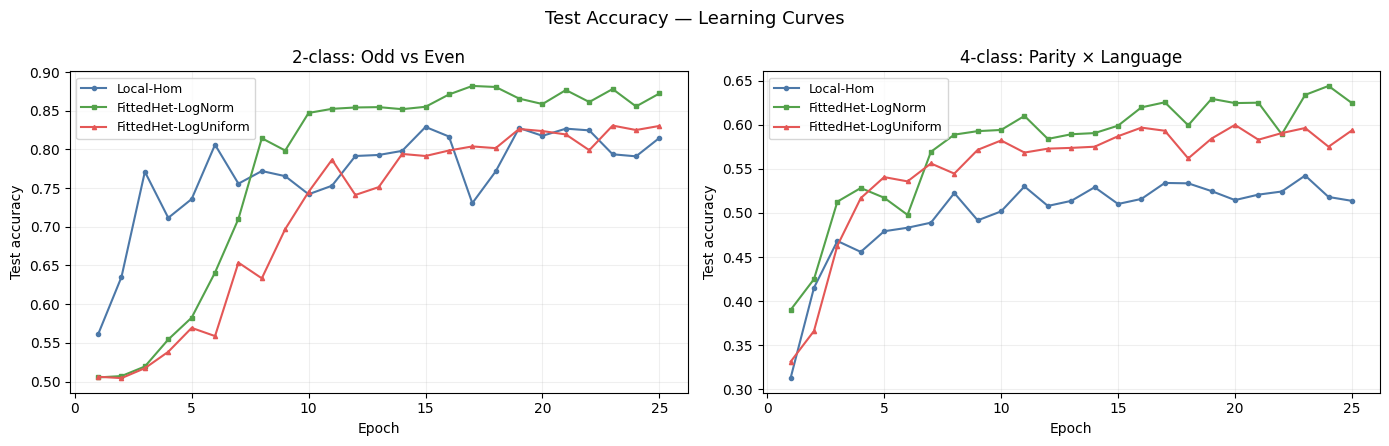

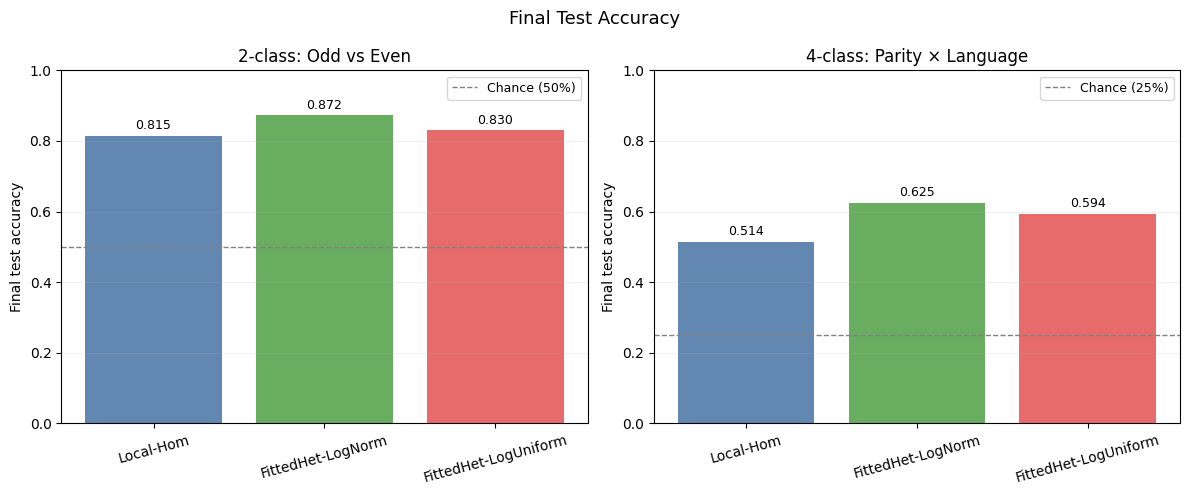

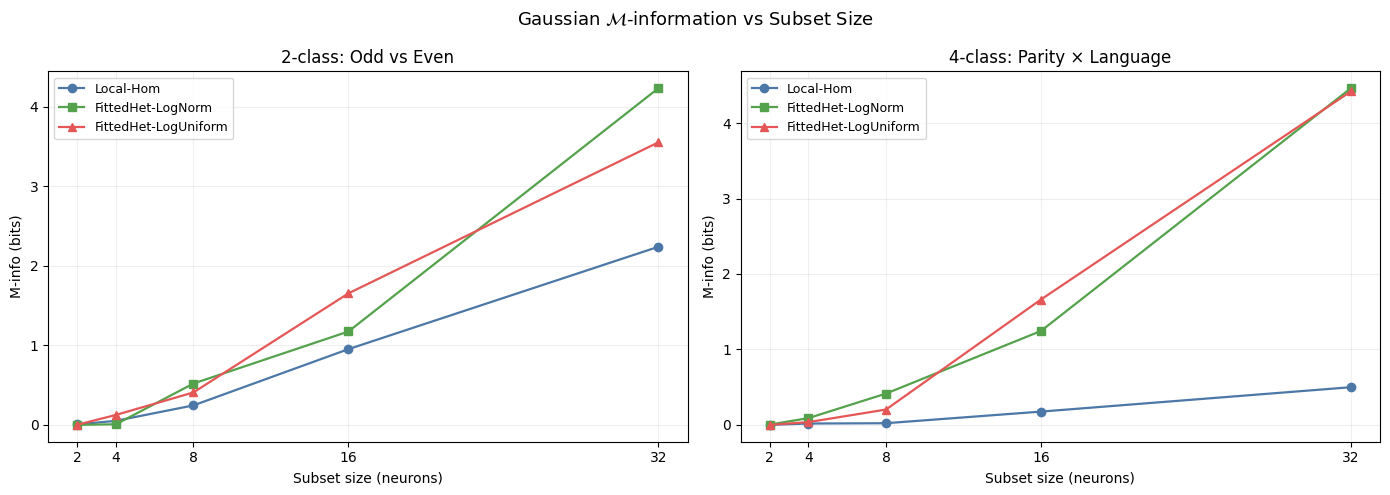

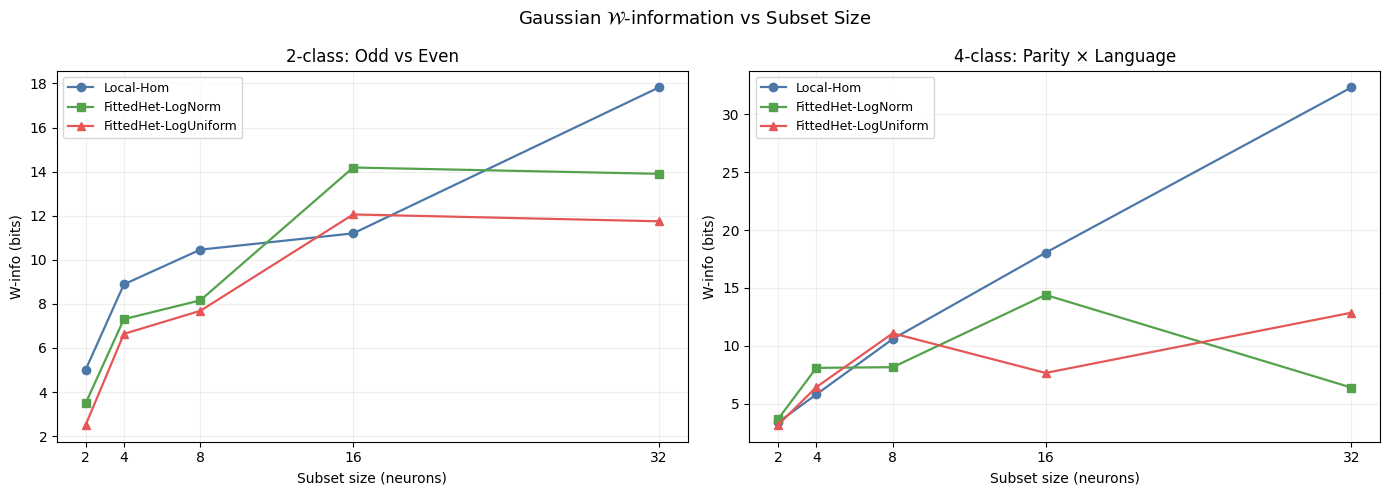


Key                              Acc        M@2      M@4      M@8     M@16     M@32
---------------------------------------------------------------------------------
2class_local_hom               0.815     0.0024   0.0480   0.2421   0.9496   2.2371
2class_fittedhet_ln            0.872    -0.0032   0.0045   0.5170   1.1714   4.2318
2class_fittedhet_lu            0.830    -0.0017   0.1221   0.4050   1.6512   3.5510
4class_local_hom               0.514    -0.0028   0.0149   0.0192   0.1734   0.4971
4class_fittedhet_ln            0.625     0.0011   0.0871   0.4126   1.2433   4.4662
4class_fittedhet_lu            0.594    -0.0029   0.0338   0.2004   1.6609   4.4241


In [19]:
required = ["all_results"]
missing  = [n for n in required if n not in globals()]
if missing:
    raise RuntimeError(f"Run the M-info cell first. Missing: {missing}")

arch_labels = ["Local-Hom", "FittedHet-LogNorm", "FittedHet-LogUniform"]
keys_2c     = ["2class_local_hom", "2class_fittedhet_ln", "2class_fittedhet_lu"]
keys_4c     = ["4class_local_hom", "4class_fittedhet_ln", "4class_fittedhet_lu"]
COLORS      = ["#4c78a8", "#54a24b", "#e45756"]
LINE_STYLES = ["-o", "-s", "-^"]

# ── 1. Learning curves ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
for ax, keys, title in [
    (axes[0], keys_2c, "2-class: Odd vs Even"),
    (axes[1], keys_4c, "4-class: Parity ÁELanguage"),
]:
    for key, lbl, col, ls in zip(keys, arch_labels, COLORS, LINE_STYLES):
        h = all_results.get(key, {}).get("history")
        if h is None:
            continue
        ep = np.arange(1, len(h["test_acc"]) + 1)
        ax.plot(ep, h["test_acc"], color=col, marker=ls[1], markersize=3, label=lbl)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test accuracy")
    ax.set_title(title)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
plt.suptitle("Test Accuracy  ELearning Curves", fontsize=13)
plt.tight_layout()
plt.show()

# ── 2. Final accuracy bars ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, keys, title, chance in [
    (axes[0], keys_2c, "2-class: Odd vs Even",       0.50),
    (axes[1], keys_4c, "4-class: Parity ÁELanguage",  0.25),
]:
    accs = [all_results.get(k, {}).get("final_test_acc", 0.0) for k in keys]
    bars = ax.bar(arch_labels, accs, color=COLORS, alpha=0.88)
    ax.axhline(chance, color="gray", linestyle="--", linewidth=1,
               label=f"Chance ({chance:.0%})")
    ax.set_ylabel("Final test accuracy")
    ax.set_title(title)
    ax.set_ylim(0, 1.0)
    ax.grid(axis="y", alpha=0.2)
    ax.legend(fontsize=9)
    for bar, val in zip(bars, accs):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.01,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.tick_params(axis="x", rotation=15)
plt.suptitle("Final Test Accuracy", fontsize=13)
plt.tight_layout()
plt.show()

# ── 3. M-info vs subset size ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, keys, title in [
    (axes[0], keys_2c, "2-class: Odd vs Even"),
    (axes[1], keys_4c, "4-class: Parity ÁELanguage"),
]:
    for key, lbl, col, ls in zip(keys, arch_labels, COLORS, LINE_STYLES):
        sweep = all_results.get(key, {}).get("m_info_by_subset", {})
        if not sweep:
            continue
        xs = sorted(sweep.keys())
        ms = [sweep[k]["M_bits"] if sweep[k] and np.isfinite(sweep[k].get("M_bits", np.nan))
              else np.nan for k in xs]
        ax.plot(xs, ms, ls, color=col, markersize=6, linewidth=1.6, label=lbl)
    ax.set_xlabel("Subset size (neurons)")
    ax.set_ylabel("M-info (bits)")
    ax.set_title(title)
    ax.set_xticks(M_INFO_SUBSET_SIZES)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
plt.suptitle(f"Gaussian $\\mathcal{{M}}$-information vs Subset Size", fontsize=13)
plt.tight_layout()
plt.show()

# ── 4. W-info vs subset size ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, keys, title in [
    (axes[0], keys_2c, "2-class: Odd vs Even"),
    (axes[1], keys_4c, "4-class: Parity ÁELanguage"),
]:
    for key, lbl, col, ls in zip(keys, arch_labels, COLORS, LINE_STYLES):
        sweep = all_results.get(key, {}).get("m_info_by_subset", {})
        if not sweep:
            continue
        xs = sorted(sweep.keys())
        ws = [sweep[k]["W_bits"] if sweep[k] and np.isfinite(sweep[k].get("W_bits", np.nan))
              else np.nan for k in xs]
        ax.plot(xs, ws, ls, color=col, markersize=6, linewidth=1.6, label=lbl)
    ax.set_xlabel("Subset size (neurons)")
    ax.set_ylabel("W-info (bits)")
    ax.set_title(title)
    ax.set_xticks(M_INFO_SUBSET_SIZES)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=9)
plt.suptitle("Gaussian $\\mathcal{W}$-information vs Subset Size", fontsize=13)
plt.tight_layout()
plt.show()

# ── 5. Summary table ──────────────────────────────────────────────────────────
print(f"\n{'Key':28s}  {'Acc':>6}  ", end="")
for k in M_INFO_SUBSET_SIZES:
    print(f"{'M@'+str(k):>9}", end="")
print()
print("-" * (36 + 9 * len(M_INFO_SUBSET_SIZES)))
for key in [*keys_2c, *keys_4c]:
    res   = all_results.get(key, {})
    acc   = res.get("final_test_acc", float("nan"))
    sweep = res.get("m_info_by_subset", {})
    print(f"{key:28s}  {acc:6.3f}  ", end="")
    for k in M_INFO_SUBSET_SIZES:
        r = sweep.get(k)
        m = r["M_bits"] if (r and np.isfinite(r.get("M_bits", np.nan))) else float("nan")
        print(f"{m:9.4f}", end="")
    print()


## Spike-Tensor Reanalysis (Observed M/W)

Recompute the information sweeps using hidden spikes (`spk`) instead of hidden membrane (`mem`) and compare both representations side-by-side.

Observed mem vs spk sweep config:
{'max_batches': 2, 'downsample_stride': 4, 'lag': 1, 'ridge': 0.01}

Computing observed sweeps for subset sizes [2, 4, 8, 16, 32]...
  2class_local_hom             [mem]  k=2: M=0.0024(W=5.0172)  k=4: M=0.0480(W=8.8878)  k=8: M=0.2421(W=10.4609)  k=16: M=0.9496(W=11.1992)  k=32: M=2.2371(W=17.8189)
  2class_local_hom             [spk]  k=2: M=-0.0018(W=3.9081)  k=4: M=0.0462(W=7.0720)  k=8: M=0.0621(W=10.8084)  k=16: M=0.5764(W=14.6795)  k=32: M=2.0185(W=13.8500)
  2class_fittedhet_ln          [mem]  k=2: M=-0.0032(W=3.4972)  k=4: M=0.0045(W=7.3076)  k=8: M=0.5170(W=8.1614)  k=16: M=1.1714(W=14.1868)  k=32: M=4.2318(W=13.9012)
  2class_fittedhet_ln          [spk]  k=2: M=-0.0026(W=5.0839)  k=4: M=0.0429(W=8.4332)  k=8: M=0.2478(W=12.6587)  k=16: M=1.7921(W=7.2926)  k=32: M=4.3292(W=10.9549)
  2class_fittedhet_lu          [mem]  k=2: M=-0.0017(W=2.5130)  k=4: M=0.1221(W=6.6396)  k=8: M=0.4050(W=7.6865)  k=16: M=1.6512(W=12.0582)  k=32: M=3.5510(W=11.747

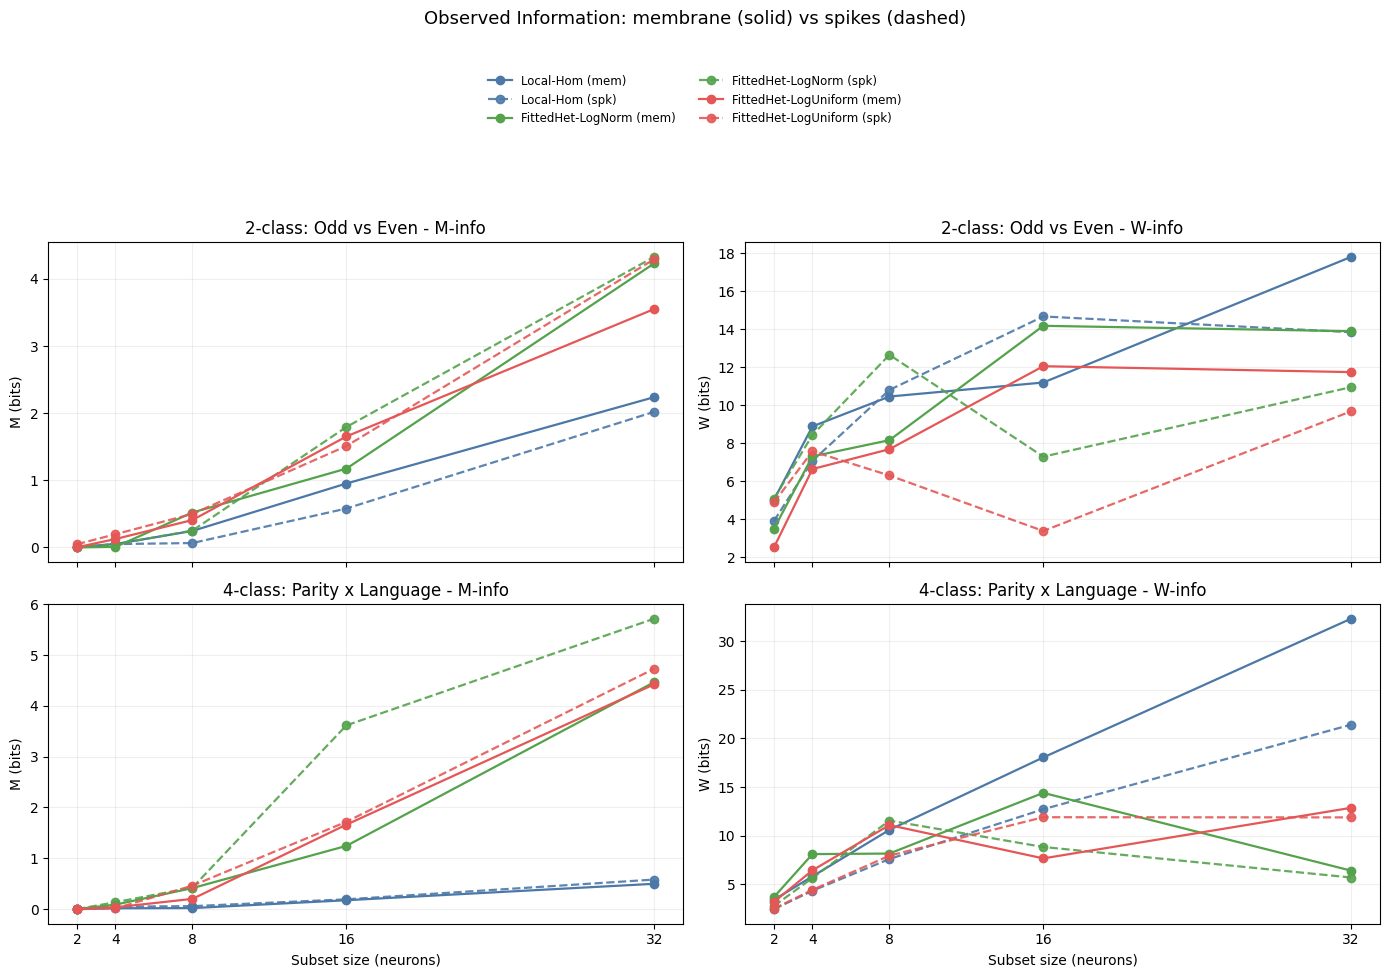

In [23]:
import pandas as pd

required = [
    "all_results", "SHD_TEST_CACHE", "M_INFO_SUBSET_SIZES",
    "model_2c_hom", "prms_2c_hom",
    "model_2c_ln", "prms_2c_ln",
    "model_2c_lu", "prms_2c_lu",
    "model_4c_hom", "prms_4c_hom",
    "model_4c_ln", "prms_4c_ln",
    "model_4c_lu", "prms_4c_lu",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run prior setup/training cells first. Missing: {missing}")

eval_pairs = [
    ("2class_local_hom", model_2c_hom, prms_2c_hom),
    ("2class_fittedhet_ln", model_2c_ln, prms_2c_ln),
    ("2class_fittedhet_lu", model_2c_lu, prms_2c_lu),
    ("4class_local_hom", model_4c_hom, prms_4c_hom),
    ("4class_fittedhet_ln", model_4c_ln, prms_4c_ln),
    ("4class_fittedhet_lu", model_4c_lu, prms_4c_lu),
]

subset_sizes = [int(k) for k in M_INFO_SUBSET_SIZES]
OBS_CONFIG = {
    "max_batches": 2,
    "downsample_stride": 4,
    "lag": 1,
    "ridge": 1e-2,
}

print("Observed mem vs spk sweep config:")
print(OBS_CONFIG)


@torch.no_grad()
def collect_hidden_tensor_matrix(model, prms, data_source, tensor_key="mem", max_batches=2, downsample_stride=4):
    """Collect hidden trajectories as [neurons, timepoints] for membrane or spikes."""
    stride = max(int(downsample_stride), 1)
    nb_hidden = int(model.network[0].output_size)
    chunks = []
    ctx = shd_open_cached if _is_cache(data_source) else shd_open

    with ctx(data_source) as (units, times, labels):
        for bidx, (x, _) in enumerate(
            shd_generator(units, times, labels, prms, shuffle=False, epoch=0, drop_last=False)
        ):
            if bidx >= max_batches:
                break
            x = x.to(DEVICE)
            layer_recs = model(0, 0, x)
            if tensor_key == "mem":
                hidden = layer_recs[0][1]
            elif tensor_key == "spk":
                hidden = layer_recs[0][0]
            else:
                raise ValueError(f"Unknown tensor_key={tensor_key}")

            hidden = hidden[:, ::stride, :].detach().cpu().numpy()
            hidden = np.transpose(hidden, (2, 0, 1)).reshape(nb_hidden, -1)
            chunks.append(hidden)

    if not chunks:
        raise RuntimeError(f"No batches collected for tensor_key={tensor_key}")

    return np.concatenate(chunks, axis=1)


def compute_tensor_sweep_from_hidden(all_hidden, subset_sizes, lag=1, ridge=1e-2):
    results = {}
    nb_hidden = int(all_hidden.shape[0])
    for k in subset_sizes:
        k = int(k)
        idx = np.linspace(0, nb_hidden - 1, min(k, nb_hidden), dtype=int)
        try:
            r = _compute_wm_from_matrix(all_hidden[idx, :], lag=lag, ridge=ridge)
            r["subset_size"] = k
            r["indices"] = idx.tolist()
            results[k] = r
        except Exception as exc:
            results[k] = {
                "subset_size": k,
                "indices": idx.tolist(),
                "error": str(exc),
                "W_bits": float("nan"),
                "M_bits": float("nan"),
            }
    return results


_tensor_hidden_cache = {}
tensor_observed_sweeps = {}

print(f"\nComputing observed sweeps for subset sizes {subset_sizes}...")
for key, model, prms in eval_pairs:
    _tensor_hidden_cache[key] = {}
    for tensor_key in ["mem", "spk"]:
        hidden_data = collect_hidden_tensor_matrix(
            model,
            prms,
            SHD_TEST_CACHE,
            tensor_key=tensor_key,
            max_batches=OBS_CONFIG["max_batches"],
            downsample_stride=OBS_CONFIG["downsample_stride"],
        )
        _tensor_hidden_cache[key][tensor_key] = hidden_data

        sweep = compute_tensor_sweep_from_hidden(
            hidden_data,
            subset_sizes,
            lag=OBS_CONFIG["lag"],
            ridge=OBS_CONFIG["ridge"],
        )
        tensor_observed_sweeps[(key, tensor_key)] = sweep

        parts = "  ".join(
            f"k={k}: M={row['M_bits']:.4f}(W={row['W_bits']:.4f})"
            if row and np.isfinite(row.get("M_bits", np.nan)) and np.isfinite(row.get("W_bits", np.nan))
            else f"k={k}: FAIL"
            for k, row in sorted(sweep.items())
        )
        print(f"  {key:28s} [{tensor_key}]  {parts}")

    all_results[key]["m_info_by_subset_mem"] = tensor_observed_sweeps[(key, "mem")]
    all_results[key]["m_info_by_subset_spk"] = tensor_observed_sweeps[(key, "spk")]


comparison_rows = []
for key, _, _ in eval_pairs:
    label = all_results.get(key, {}).get("label", key)
    task = all_results.get(key, {}).get("task", "?")
    mem_sweep = tensor_observed_sweeps[(key, "mem")]
    spk_sweep = tensor_observed_sweeps[(key, "spk")]

    for k in subset_sizes:
        mem_row = mem_sweep.get(k, {})
        spk_row = spk_sweep.get(k, {})
        comparison_rows.append(
            {
                "key": key,
                "label": label,
                "task": task,
                "subset_size": int(k),
                "M_mem": float(mem_row.get("M_bits", np.nan)),
                "W_mem": float(mem_row.get("W_bits", np.nan)),
                "M_spk": float(spk_row.get("M_bits", np.nan)),
                "W_spk": float(spk_row.get("W_bits", np.nan)),
            }
        )

tensor_observed_comparison_df = pd.DataFrame(comparison_rows)
tensor_observed_comparison_df["delta_M_spk_minus_mem"] = (
    tensor_observed_comparison_df["M_spk"] - tensor_observed_comparison_df["M_mem"]
)
tensor_observed_comparison_df["delta_W_spk_minus_mem"] = (
    tensor_observed_comparison_df["W_spk"] - tensor_observed_comparison_df["W_mem"]
)

print("\nMean observed deltas (spk - mem):")
mean_delta = (
    tensor_observed_comparison_df.groupby(["key", "label", "task"], as_index=False)[
        ["delta_M_spk_minus_mem", "delta_W_spk_minus_mem"]
    ]
    .mean()
    .sort_values(["task", "key"])
)
print(mean_delta.to_string(index=False, float_format=lambda v: f"{v:.4f}"))

print("\nObserved M table (mem):")
mem_table = tensor_observed_comparison_df.pivot(index="subset_size", columns="key", values="M_mem").sort_index()
print(mem_table.to_string(float_format=lambda v: f"{v:.4f}"))

print("\nObserved M table (spk):")
spk_table = tensor_observed_comparison_df.pivot(index="subset_size", columns="key", values="M_spk").sort_index()
print(spk_table.to_string(float_format=lambda v: f"{v:.4f}"))

keys_2c = ["2class_local_hom", "2class_fittedhet_ln", "2class_fittedhet_lu"]
keys_4c = ["4class_local_hom", "4class_fittedhet_ln", "4class_fittedhet_lu"]
color_map = {
    "local_hom": COLORS[0],
    "fittedhet_ln": COLORS[1],
    "fittedhet_lu": COLORS[2],
}


def _arch_from_key(key):
    if "local_hom" in key:
        return "local_hom"
    if "fittedhet_ln" in key:
        return "fittedhet_ln"
    return "fittedhet_lu"


fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
for row_idx, (task_keys, task_title) in enumerate(
    [
        (keys_2c, "2-class: Odd vs Even"),
        (keys_4c, "4-class: Parity x Language"),
    ]
):
    for key in task_keys:
        label = all_results[key]["label"]
        color = color_map[_arch_from_key(key)]
        for tensor_key, linestyle, alpha in [("mem", "-", 1.0), ("spk", "--", 0.9)]:
            sweep = tensor_observed_sweeps[(key, tensor_key)]
            xs = sorted(sweep.keys())
            m_vals = [
                sweep[k]["M_bits"] if sweep[k] and np.isfinite(sweep[k].get("M_bits", np.nan)) else np.nan
                for k in xs
            ]
            w_vals = [
                sweep[k]["W_bits"] if sweep[k] and np.isfinite(sweep[k].get("W_bits", np.nan)) else np.nan
                for k in xs
            ]
            axes[row_idx, 0].plot(
                xs,
                m_vals,
                linestyle=linestyle,
                marker="o",
                color=color,
                alpha=alpha,
                linewidth=1.6,
                label=f"{label} ({tensor_key})",
            )
            axes[row_idx, 1].plot(
                xs,
                w_vals,
                linestyle=linestyle,
                marker="o",
                color=color,
                alpha=alpha,
                linewidth=1.6,
                label=f"{label} ({tensor_key})",
            )

    axes[row_idx, 0].set_title(f"{task_title} - M-info")
    axes[row_idx, 0].set_ylabel("M (bits)")
    axes[row_idx, 1].set_title(f"{task_title} - W-info")
    axes[row_idx, 1].set_ylabel("W (bits)")

for ax in axes[-1, :]:
    ax.set_xlabel("Subset size (neurons)")
for ax in axes.flat:
    ax.set_xticks(subset_sizes)
    ax.grid(alpha=0.2)

handles, labels = axes[0, 0].get_legend_handles_labels()
legend_map = dict(zip(labels, handles))
fig.legend(
    legend_map.values(),
    legend_map.keys(),
    loc="upper center",
    ncol=2,
    fontsize=8.5,
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
plt.suptitle("Observed Information: membrane (solid) vs spikes (dashed)", fontsize=13, y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.show()


## Null Z-Score Estimation (mem vs spk)

Estimate subset-level null distributions for both membrane and spike information by time-shuffling each neuron independently, then compute z-scores and one-sided p-values for observed M and W.

Null z-score config:
{'null_samples_subset': 100, 'seed': 12345, 'lag': 1, 'ridge': 0.01, 'null_mode': 'iid', 'fast_null_solver': True, 'cache_namespace': 'parity_mem_spk_subset_scoring', 'use_existing_null_cache_only': False, 'save_every': 20}

[mem] Null cache file: C:\Users\Priya\Desktop\research project (SNN Info Theory)\Project Files\Null Caches\parity_mem_spk_subset_scoring_mem_zero_m_subset_null_cache_iid_lag1_ridge1e-02_n100_fast_distr_newton.json
[mem] Loaded cache entries: 0
cache[mem] 1/8 subset=02 build
  subset=02 draws 50/100
  subset=02 draws 100/100
  subset=02 complete validM=100 errors=000
cache[mem] 2/8 subset=04 build
  subset=04 draws 50/100
  subset=04 draws 100/100
  subset=04 complete validM=099 errors=001
cache[mem] 3/8 subset=08 build
  subset=08 draws 50/100
  subset=08 draws 100/100
  subset=08 complete validM=100 errors=000
cache[mem] 4/8 subset=16 build
  subset=16 draws 50/100
  subset=16 draws 100/100
  subset=16 complete validM=100 errors=000
cache[mem]

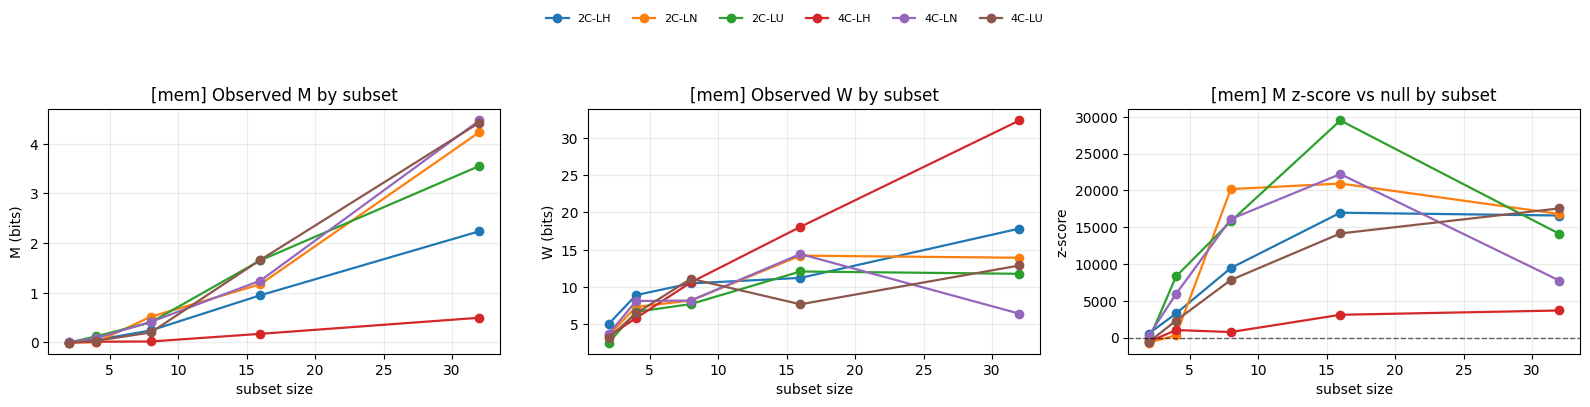


[mem] Subset=32 null-score summary
----------------------------------------------------------------------
2class_local_hom         M=+2.2371  null=+0.0022  z=+16576.68  p=0.0099
2class_fittedhet_ln      M=+4.2318  null=+0.0043  z=+16783.84  p=0.0099
2class_fittedhet_lu      M=+3.5510  null=+0.0043  z=+14080.83  p=0.0099
4class_local_hom         M=+0.4971  null=+0.0022  z=+3671.06  p=0.0099
4class_fittedhet_ln      M=+4.4662  null=+0.0086  z=+7726.01  p=0.0099
4class_fittedhet_lu      M=+4.4241  null=+0.0043  z=+17547.42  p=0.0099

[mem] Largest valid subset summary
----------------------------------------------------------------------
2class_local_hom         subset=32 M=+2.2371 z=+16576.68 p=0.0099
2class_fittedhet_ln      subset=32 M=+4.2318 z=+16783.84 p=0.0099
2class_fittedhet_lu      subset=32 M=+3.5510 z=+14080.83 p=0.0099
4class_local_hom         subset=32 M=+0.4971 z=+3671.06 p=0.0099
4class_fittedhet_ln      subset=32 M=+4.4662 z=+7726.01 p=0.0099
4class_fittedhet_lu      sub

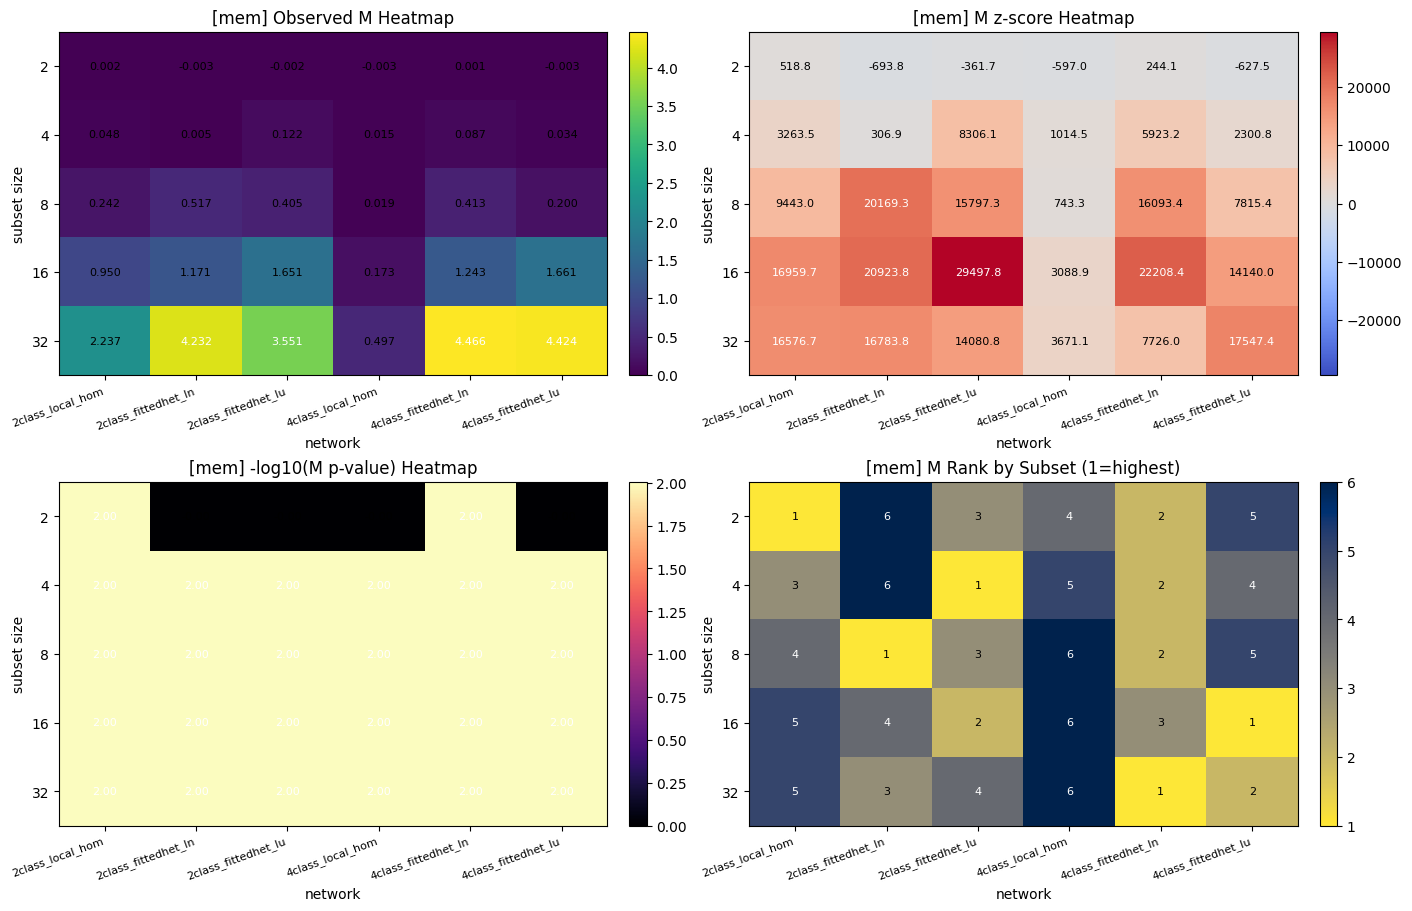

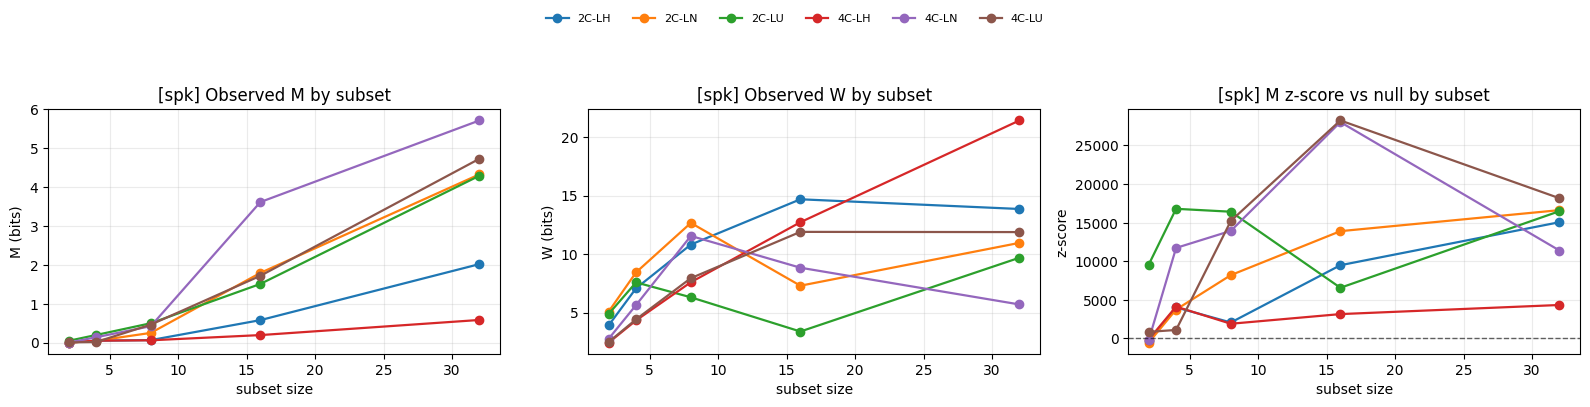


[spk] Subset=32 null-score summary
----------------------------------------------------------------------
2class_local_hom         M=+2.0185  null=+0.0022  z=+15048.59  p=0.0099
2class_fittedhet_ln      M=+4.3292  null=+0.0043  z=+16613.24  p=0.0099
2class_fittedhet_lu      M=+4.2942  null=+0.0043  z=+16478.61  p=0.0099
4class_local_hom         M=+0.5806  null=+0.0022  z=+4317.09  p=0.0099
4class_fittedhet_ln      M=+5.7165  null=+0.0086  z=+11377.60  p=0.0099
4class_fittedhet_lu      M=+4.7308  null=+0.0043  z=+18155.94  p=0.0099

[spk] Largest valid subset summary
----------------------------------------------------------------------
2class_local_hom         subset=32 M=+2.0185 z=+15048.59 p=0.0099
2class_fittedhet_ln      subset=32 M=+4.3292 z=+16613.24 p=0.0099
2class_fittedhet_lu      subset=32 M=+4.2942 z=+16478.61 p=0.0099
4class_local_hom         subset=32 M=+0.5806 z=+4317.09 p=0.0099
4class_fittedhet_ln      subset=32 M=+5.7165 z=+11377.60 p=0.0099
4class_fittedhet_lu      s

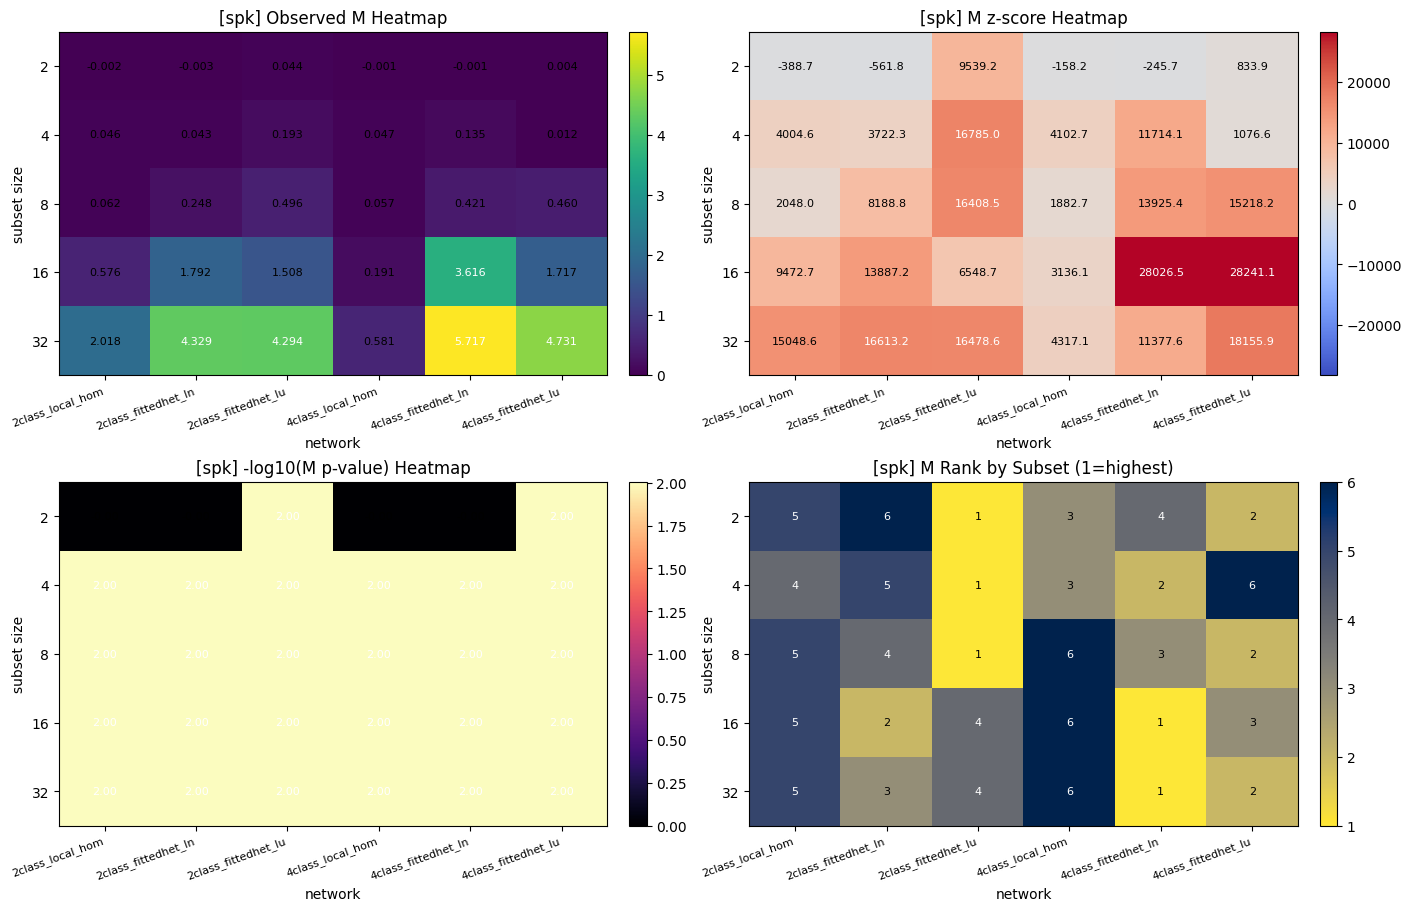


Mem vs Spk delta summary (Stage-4 style inputs)
----------------------------------------------------------------------
                key  subset_size   M_mem   M_spk  delta_M_spk_minus_mem     Mz_mem     Mz_spk  delta_Mz_spk_minus_mem
2class_fittedhet_ln            2 -0.0032 -0.0026                 0.0006  -693.8419  -561.8186                132.0233
2class_fittedhet_ln            4  0.0045  0.0429                 0.0384   306.8881  3722.3226               3415.4345
2class_fittedhet_ln            8  0.5170  0.2478                -0.2692 20169.2704  8188.7928             -11980.4776
2class_fittedhet_ln           16  1.1714  1.7921                 0.6207 20923.8403 13887.2352              -7036.6050
2class_fittedhet_ln           32  4.2318  4.3292                 0.0974 16783.8413 16613.2363               -170.6051
2class_fittedhet_lu            2 -0.0017  0.0441                 0.0458  -361.7384  9539.1819               9900.9202
2class_fittedhet_lu            4  0.1221  0.1934      

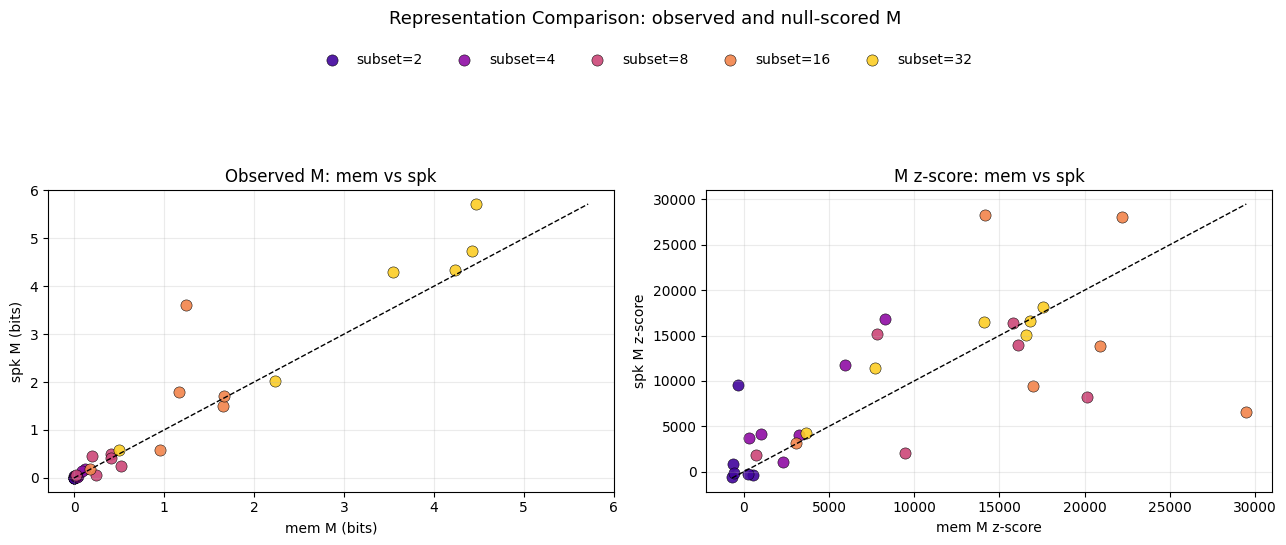

In [26]:
import pandas as pd
from matplotlib.colors import TwoSlopeNorm

required = ["tensor_observed_sweeps", "all_results", "M_INFO_SUBSET_SIZES", "PROJECT_ROOT"]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(f"Run the observed mem/spk section first. Missing: {missing}")

NULL_Z_CONFIG = {
    # Match sample subset scoring Stage 3 draw count and cache cadence.
    "null_samples_subset": 100,
    "seed": 12345,
    "lag": 1,
    "ridge": float(OBS_CONFIG.get("ridge", 1e-2) if "OBS_CONFIG" in globals() else 1e-2),
    "null_mode": "iid",
    "fast_null_solver": True,
    "cache_namespace": "parity_mem_spk_subset_scoring",
    "use_existing_null_cache_only": False,
    "save_every": 20,
}

subset_sizes = sorted({int(v) for v in M_INFO_SUBSET_SIZES})

def _preferred_key_order(keys):
    preferred = [
        "2class_local_hom",
        "2class_fittedhet_ln",
        "2class_fittedhet_lu",
        "4class_local_hom",
        "4class_fittedhet_ln",
        "4class_fittedhet_lu",
    ]
    ordered = [k for k in preferred if k in keys]
    ordered.extend([k for k in sorted(keys) if k not in ordered])
    return ordered

network_keys = _preferred_key_order({k for k, _ in tensor_observed_sweeps.keys()})

tensor_keys = ["mem", "spk"]
output_dir = PROJECT_ROOT / "Project Files"
null_cache_dir = output_dir / "Null Caches"
null_cache_dir.mkdir(parents=True, exist_ok=True)

print("Null z-score config:")
print(NULL_Z_CONFIG)


def _slugify(value):
    text = str(value).strip().lower()
    chars = []
    for ch in text:
        if ch.isalnum():
            chars.append(ch)
        else:
            chars.append("_")
    slug = "".join(chars)
    while "__" in slug:
        slug = slug.replace("__", "_")
    return slug.strip("_") or "value"


def _sanitize_for_json(obj):
    if isinstance(obj, dict):
        return {str(k): _sanitize_for_json(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [_sanitize_for_json(v) for v in obj]
    if isinstance(obj, (np.integer,)):
        return int(obj)
    if isinstance(obj, (np.floating, float)):
        value = float(obj)
        if not np.isfinite(value):
            return None
        return value
    if isinstance(obj, (np.bool_, bool)):
        return bool(obj)
    return obj


def _null_cache_key(nvar, nsamples, lag, ridge, n_null, null_mode):
    key_parts = [int(nvar), int(nsamples), int(lag), float(ridge), int(n_null), str(null_mode)]
    return json.dumps(key_parts, separators=(",", ":"))


def _cache_file_name(cache_namespace, tensor_key, null_mode, lag, ridge, n_null, solver_tag):
    namespace = _slugify(cache_namespace)
    ridge_tag = "{:.0e}".format(float(ridge)).replace("+", "")
    return (
        f"{namespace}_{tensor_key}_zero_m_subset_null_cache_"
        f"{null_mode}_lag{int(lag)}_ridge{ridge_tag}_n{int(n_null)}_{solver_tag}.json"
    )


def _coerce_float_list(values):
    out = []
    for value in values:
        try:
            out.append(float(value))
        except Exception:
            out.append(float("nan"))
    return out


def _make_null_distribution(null_w, null_m, n_null_target, null_mode, fast_null_solver):
    null_w_arr = np.asarray(null_w, dtype=np.float64)
    null_m_arr = np.asarray(null_m, dtype=np.float64)
    valid_pair = np.isfinite(null_w_arr) & np.isfinite(null_m_arr)
    errors = int(valid_pair.size - int(valid_pair.sum()))
    return {
        "null_W_values": [float(v) if np.isfinite(v) else float("nan") for v in null_w_arr],
        "null_M_values": [float(v) if np.isfinite(v) else float("nan") for v in null_m_arr],
        "n_null": int(n_null_target),
        "n_null_generated": int(null_w_arr.size),
        "n_null_errors": int(errors),
        "n_null_valid_W": int(np.isfinite(null_w_arr).sum()),
        "n_null_valid_M": int(np.isfinite(null_m_arr).sum()),
        "null_mode": str(null_mode),
        "null_solver": "fast_distr_newton" if fast_null_solver else "full_data_path",
    }


def load_json_cache(cache_path):
    cache_path = Path(cache_path)
    if not cache_path.exists():
        return {}, {}
    with open(cache_path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)
    metadata = payload.get("metadata", {}) if isinstance(payload, dict) else {}
    cache = payload.get("cache", {}) if isinstance(payload, dict) else {}
    if not isinstance(metadata, dict):
        metadata = {}
    if not isinstance(cache, dict):
        cache = {}
    return metadata, cache


def save_json_cache(cache, cache_path, metadata=None):
    cache_path = Path(cache_path)
    cache_path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "metadata": _sanitize_for_json(metadata or {}),
        "cache": _sanitize_for_json(cache),
    }
    tmp_path = cache_path.with_suffix(cache_path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(cache_path)


def load_sweep_results(path):
    path = Path(path)
    if not path.exists():
        return []
    with open(path, "r", encoding="utf-8") as handle:
        payload = json.load(handle)
    if isinstance(payload, dict) and isinstance(payload.get("results"), list):
        return payload["results"]
    if isinstance(payload, list):
        return payload
    return []


def save_sweep_results(results, path, metadata=None):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    payload = {
        "metadata": _sanitize_for_json(metadata or {}),
        "results": _sanitize_for_json(results),
    }
    tmp_path = path.with_suffix(path.suffix + ".tmp")
    with open(tmp_path, "w", encoding="utf-8") as handle:
        json.dump(payload, handle, indent=2)
    tmp_path.replace(path)


def _resume_index(results):
    indexed = {}
    for row in results:
        if isinstance(row, dict) and "subset_size" in row:
            try:
                indexed[int(row["subset_size"])] = row
            except Exception:
                pass
    return indexed


def simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode="iid"):
    if str(mode) != "iid":
        raise ValueError(f"Unsupported null mode: {mode}")
    return rng.normal(0.0, 1.0, size=(int(nvar), int(nsamples))).astype(np.float64)


def _regularize_covariance(cov, ridge=1e-2):
    cov = np.asarray(cov, dtype=np.float64)
    cov = np.nan_to_num(cov, nan=0.0, posinf=0.0, neginf=0.0)
    cov = 0.5 * (cov + cov.T)
    scale = np.trace(cov) / max(cov.shape[0], 1)
    if not np.isfinite(scale) or scale <= 0.0:
        scale = 1.0
    cov = cov + float(ridge) * scale * np.eye(cov.shape[0], dtype=np.float64)
    return cov


def _compute_w_m_from_null_hidden_fast(null_hidden, lag=1, ridge=1e-2):
    lagged_cov = _regularize_covariance(get_cov(null_hidden, t=int(lag)), ridge=ridge)
    with io.StringIO() as buffer, redirect_stdout(buffer):
        w_bits, m_bits = W_M_calculator(
            lagged_cov,
            option="distr",
            type="gaussian",
            unit="bits",
            verbose=False,
            optimiser="Newton",
            options=None,
        )
    if not (np.isfinite(w_bits) and np.isfinite(m_bits)):
        raise RuntimeError("Fast null W/M calculation returned non-finite values.")
    return {
        "W_bits": float(w_bits),
        "M_bits": float(m_bits),
        "optimiser": "Newton",
    }


def build_zero_m_null_distribution(
    nvar,
    nsamples,
    lag=1,
    ridge=1e-2,
    n_null=200,
    null_mode="iid",
    seed=12345,
    cache=None,
    cache_key=None,
    fast_null_solver=True,
    cache_save_callback=None,
    save_every=20,
    progress_label=None,
):
    target_n = int(n_null)

    null_w = []
    null_m = []
    if cache is not None and cache_key is not None and cache_key in cache:
        existing = cache[cache_key]
        null_w = _coerce_float_list(existing.get("null_W_values", []))
        null_m = _coerce_float_list(existing.get("null_M_values", []))
        paired_len = min(len(null_w), len(null_m))
        null_w = null_w[:paired_len]
        null_m = null_m[:paired_len]
        if paired_len >= target_n:
            return _make_null_distribution(null_w[:target_n], null_m[:target_n], target_n, null_mode, fast_null_solver)

    start_idx = len(null_w)

    rng = np.random.default_rng(seed)
    for _ in range(start_idx):
        _ = simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode=null_mode)

    for draw_index in range(start_idx, target_n):
        null_hidden = simulate_zero_m_gaussian_hidden(nvar, nsamples, rng, mode=null_mode)
        try:
            if fast_null_solver:
                null_result = _compute_w_m_from_null_hidden_fast(null_hidden, lag=lag, ridge=ridge)
            else:
                null_result = _compute_wm_from_matrix(null_hidden, lag=lag, ridge=ridge)
            null_w.append(float(null_result["W_bits"]))
            null_m.append(float(null_result["M_bits"]))
        except Exception:
            null_w.append(float("nan"))
            null_m.append(float("nan"))

        if cache is not None and cache_key is not None:
            cache[cache_key] = _make_null_distribution(null_w, null_m, target_n, null_mode, fast_null_solver)
            if cache_save_callback is not None and (((draw_index + 1) % max(1, int(save_every)) == 0) or (draw_index + 1 == target_n)):
                cache_save_callback(cache)

        if progress_label is not None and (((draw_index + 1) % 50 == 0) or (draw_index + 1 == target_n)):
            print(f"{progress_label} draws {draw_index + 1}/{target_n}")

    distribution = _make_null_distribution(null_w, null_m, target_n, null_mode, fast_null_solver)
    if cache is not None and cache_key is not None:
        cache[cache_key] = distribution
    return distribution


def prepare_shared_null_cache(
    observed_sweeps_by_network,
    tensor_key,
    lag=1,
    ridge=1e-2,
    n_null=200,
    null_mode="iid",
    cache=None,
    cache_path=None,
    cache_metadata=None,
    fast_null_solver=True,
    save_every=20,
):
    cache = {} if cache is None else cache
    solver_tag = "fast_distr_newton" if fast_null_solver else "full_data_path"
    cache_mode = f"{null_mode}|{solver_tag}|tensor={tensor_key}"

    jobs = {}
    for _, observed_results in observed_sweeps_by_network.items():
        for row in observed_results:
            if not (
                np.isfinite(row.get("observed_M_bits", np.nan))
                and np.isfinite(row.get("observed_W_bits", np.nan))
                and np.isfinite(row.get("samples", np.nan))
            ):
                continue
            subset_size = int(row["subset_size"])
            nsamples = int(row["samples"])
            key = _null_cache_key(subset_size, nsamples, lag, ridge, n_null, cache_mode)
            if key not in jobs:
                tensor_offset = 0 if tensor_key == "mem" else 50000
                jobs[key] = {
                    "subset_size": subset_size,
                    "nsamples": nsamples,
                    "seed": 100000 + tensor_offset + subset_size,
                }

    ordered_jobs = sorted(jobs.items(), key=lambda item: (item[1]["subset_size"], item[1]["nsamples"]))

    built = 0
    for index, (key, job) in enumerate(ordered_jobs, start=1):
        existing = cache.get(key)
        existing_generated = 0
        if isinstance(existing, dict):
            existing_generated = int(existing.get("n_null_generated", len(existing.get("null_M_values", []))))

        if existing_generated >= int(n_null):
            print(f"cache[{tensor_key}] {index}/{len(ordered_jobs)} subset={job['subset_size']:02d} reused")
            continue

        if existing_generated > 0:
            print(
                f"cache[{tensor_key}] {index}/{len(ordered_jobs)} "
                f"subset={job['subset_size']:02d} resume {existing_generated}/{int(n_null)}"
            )
        else:
            print(f"cache[{tensor_key}] {index}/{len(ordered_jobs)} subset={job['subset_size']:02d} build")

        distribution = build_zero_m_null_distribution(
            nvar=job["subset_size"],
            nsamples=job["nsamples"],
            lag=lag,
            ridge=ridge,
            n_null=n_null,
            null_mode=null_mode,
            seed=job["seed"],
            cache=cache,
            cache_key=key,
            fast_null_solver=fast_null_solver,
            cache_save_callback=(lambda c: save_json_cache(c, cache_path, metadata=cache_metadata)) if cache_path is not None else None,
            save_every=save_every,
            progress_label=f"  subset={job['subset_size']:02d}",
        )

        cache[key] = distribution
        built += 1
        if cache_path is not None:
            save_json_cache(cache, cache_path, metadata=cache_metadata)

        print(
            f"  subset={job['subset_size']:02d} complete "
            f"validM={distribution['n_null_valid_M']:03d} errors={distribution['n_null_errors']:03d}"
        )

    print(f"Shared null cache [{tensor_key}] ready: {len(cache)} entries ({built} built/resumed)")
    return cache


def zscore_from_null(observed_value, null_values):
    values = np.asarray(null_values, dtype=np.float64)
    values = values[np.isfinite(values)]
    if not np.isfinite(observed_value) or values.size == 0:
        return float("nan"), float("nan"), float("nan")

    mu = float(values.mean())
    if values.size > 1:
        std = float(values.std(ddof=1))
    else:
        std = float("nan")

    if np.isfinite(std) and std > 1e-12:
        z_val = float((float(observed_value) - mu) / std)
    else:
        z_val = float("nan")

    empirical_p = float((np.sum(values >= float(observed_value)) + 1.0) / (values.size + 1.0))
    return z_val, mu, empirical_p


def score_observed_row_against_null(observed_row, null_distribution):
    result = dict(observed_row)
    m_z, m_mu, m_p = zscore_from_null(observed_row["observed_M_bits"], null_distribution["null_M_values"])
    w_z, w_mu, w_p = zscore_from_null(observed_row["observed_W_bits"], null_distribution["null_W_values"])
    result.update(
        {
            "null_W_mean": float(w_mu),
            "null_M_mean": float(m_mu),
            "W_zscore": float(w_z),
            "M_zscore": float(m_z),
            "W_p_upper": float(w_p),
            "M_p_upper": float(m_p),
            "null_W_values": null_distribution["null_W_values"],
            "null_M_values": null_distribution["null_M_values"],
            "n_null": int(null_distribution["n_null"]),
            "n_null_errors": int(null_distribution["n_null_errors"]),
            "n_null_valid_W": int(null_distribution["n_null_valid_W"]),
            "n_null_valid_M": int(null_distribution["n_null_valid_M"]),
            "null_mode": str(null_distribution["null_mode"]),
            "null_solver": null_distribution.get("null_solver", "unknown"),
            "status": "ok" if null_distribution["n_null_valid_W"] > 0 and null_distribution["n_null_valid_M"] > 0 else "error",
        }
    )
    return result


def score_observed_sweep_against_zero_null(
    observed_results,
    tensor_key,
    lag=1,
    ridge=1e-2,
    n_null=200,
    null_mode="iid",
    seed=12345,
    save_path=None,
    resume=True,
    label=None,
    null_cache=None,
    share_null_across_networks=True,
    fast_null_solver=True,
    use_existing_null_cache_only=False,
):
    existing_results = load_sweep_results(save_path) if resume and save_path is not None else []
    cached_by_subset = _resume_index(existing_results)
    results = []
    solver_tag = "fast_distr_newton" if fast_null_solver else "full_data_path"

    metadata = {
        "label": label,
        "tensor": tensor_key,
        "lag": lag,
        "ridge": ridge,
        "n_null": n_null,
        "null_mode": null_mode,
        "seed": seed,
        "share_null_across_networks": bool(share_null_across_networks),
        "null_solver": solver_tag,
        "scoring_mode": "per_subset",
        "use_existing_null_cache_only": bool(use_existing_null_cache_only),
    }

    for observed_row in observed_results:
        subset_size = int(observed_row["subset_size"])
        cached = cached_by_subset.get(subset_size)
        cached_is_compatible = (
            cached is not None
            and np.isfinite(cached.get("M_zscore", np.nan))
            and int(cached.get("n_null", -1)) == int(n_null)
            and str(cached.get("null_mode", "")) == str(null_mode)
            and str(cached.get("null_solver", "")) == solver_tag
        )
        if cached_is_compatible:
            results.append(cached)
            print(
                f"subset={subset_size:02d} resumed z-score "
                f"Mz={cached.get('M_zscore', float('nan')):.2f} p={cached.get('M_p_upper', float('nan')):.4f}"
            )
            continue

        if not (np.isfinite(observed_row.get("observed_M_bits", np.nan)) and np.isfinite(observed_row.get("observed_W_bits", np.nan))):
            result = dict(observed_row)
            result.update(
                {
                    "null_W_mean": float("nan"),
                    "null_M_mean": float("nan"),
                    "W_zscore": float("nan"),
                    "M_zscore": float("nan"),
                    "W_p_upper": float("nan"),
                    "M_p_upper": float("nan"),
                    "null_W_values": [],
                    "null_M_values": [],
                    "n_null": int(n_null),
                    "n_null_errors": int(n_null),
                    "n_null_valid_W": 0,
                    "n_null_valid_M": 0,
                    "null_mode": str(null_mode),
                    "null_solver": solver_tag,
                    "status": "error",
                    "error": observed_row.get("error", "observed sweep invalid"),
                }
            )
            print(f"subset={subset_size:02d} skipped null scoring due to observed failure")
        else:
            nsamples = int(observed_row["samples"])
            cache_mode = f"{null_mode}|{solver_tag}|tensor={tensor_key}"
            if share_null_across_networks:
                cache_key = _null_cache_key(subset_size, nsamples, lag, ridge, n_null, cache_mode)
                tensor_offset = 0 if tensor_key == "mem" else 50000
                null_seed = 100000 + tensor_offset + subset_size
            else:
                cache_key = _null_cache_key(
                    subset_size,
                    nsamples,
                    lag,
                    ridge,
                    n_null,
                    f"{cache_mode}|seed{seed + subset_size}",
                )
                null_seed = seed + subset_size

            null_distribution = None
            if null_cache is not None:
                candidate = null_cache.get(cache_key)
                if isinstance(candidate, dict):
                    generated = int(candidate.get("n_null_generated", len(candidate.get("null_M_values", []))))
                    if generated >= int(n_null):
                        null_distribution = candidate

            if null_distribution is None:
                if use_existing_null_cache_only:
                    raise RuntimeError(
                        f"Missing cached null entry for tensor={tensor_key} subset={subset_size} samples={nsamples}. "
                        "Disable cache-only mode to build it."
                    )
                null_distribution = build_zero_m_null_distribution(
                    nvar=subset_size,
                    nsamples=nsamples,
                    lag=lag,
                    ridge=ridge,
                    n_null=n_null,
                    null_mode=null_mode,
                    seed=null_seed,
                    cache=null_cache,
                    cache_key=cache_key,
                    fast_null_solver=fast_null_solver,
                )

            result = score_observed_row_against_null(observed_row, null_distribution)
            print(
                f"subset={subset_size:02d} obsM={result['observed_M_bits']:.4f} "
                f"nullM={result['null_M_mean']:.4f} Mz={result['M_zscore']:.2f} p={result['M_p_upper']:.4f}"
            )

        results.append(result)
        if save_path is not None:
            save_sweep_results(results, save_path, metadata=metadata)
            print(f"  saved -> {Path(save_path).name}")

    return results


def _to_observed_rows_from_sweep(sweep_dict, subset_order):
    rows = []
    for subset_size in subset_order:
        record = sweep_dict.get(int(subset_size), {})
        m_obs = float(record.get("M_bits", np.nan))
        w_obs = float(record.get("W_bits", np.nan))
        samples = record.get("samples", np.nan)
        try:
            samples = int(samples) if np.isfinite(float(samples)) else float("nan")
        except Exception:
            samples = float("nan")
        row = {
            "subset_size": int(subset_size),
            "observed_M_bits": m_obs,
            "observed_W_bits": w_obs,
            "samples": samples,
            "status": "ok" if np.isfinite(m_obs) and np.isfinite(w_obs) else "error",
        }
        if row["status"] == "error":
            row["error"] = str(record.get("error", "observed sweep invalid"))
        rows.append(row)
    return rows


def _subset_row_values(rows, key):
    x_vals = []
    y_vals = []
    for row in rows:
        x = int(row["subset_size"])
        y = float(row.get(key, np.nan))
        if np.isfinite(y):
            x_vals.append(x)
            y_vals.append(y)
    return x_vals, y_vals


def _subset_specific_row(rows, subset_size):
    for row in rows:
        if int(row["subset_size"]) == int(subset_size):
            return row
    return None


def _print_metric_table(summary_df, metric_col, title, decimals=4):
    table = summary_df.pivot(index="subset_size", columns="key", values=metric_col).sort_index()
    print(f"\n{title}")
    print("-" * 70)
    print(table.to_string(float_format=lambda v: f"{v:.{decimals}f}"))


def _heatmap(ax, table, title, cmap="viridis", fmt="{:.2f}", center=None):
    data = table.to_numpy(dtype=float)
    finite_mask = np.isfinite(data)
    scale = float(np.nanmax(np.abs(data[finite_mask]))) if finite_mask.any() else 1.0
    if scale <= 0.0 or not np.isfinite(scale):
        scale = 1.0

    if center is None:
        im = ax.imshow(data, aspect="auto", cmap=cmap)
    else:
        norm = TwoSlopeNorm(vcenter=center, vmin=-scale, vmax=scale)
        im = ax.imshow(data, aspect="auto", cmap=cmap, norm=norm)

    ax.set_title(title)
    ax.set_xlabel("network")
    ax.set_ylabel("subset size")
    ax.set_xticks(np.arange(table.shape[1]))
    ax.set_xticklabels(table.columns, rotation=20, ha="right", fontsize=8)
    ax.set_yticks(np.arange(table.shape[0]))
    ax.set_yticklabels(table.index)

    threshold = 0.55 * scale
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = data[i, j]
            if np.isfinite(value):
                color = "white" if abs(value) > threshold else "black"
                ax.text(j, i, fmt.format(value), ha="center", va="center", color=color, fontsize=8)

    return im


def _short_name(key):
    if key == "2class_local_hom":
        return "2C-LH"
    if key == "2class_fittedhet_ln":
        return "2C-LN"
    if key == "2class_fittedhet_lu":
        return "2C-LU"
    if key == "4class_local_hom":
        return "4C-LH"
    if key == "4class_fittedhet_ln":
        return "4C-LN"
    if key == "4class_fittedhet_lu":
        return "4C-LU"
    return key


null_samples = int(NULL_Z_CONFIG["null_samples_subset"])
null_mode = str(NULL_Z_CONFIG["null_mode"])
fast_null_solver = bool(NULL_Z_CONFIG["fast_null_solver"])
cache_only_mode = bool(NULL_Z_CONFIG["use_existing_null_cache_only"])
solver_tag = "fast_distr_newton" if fast_null_solver else "full_data_path"

# Stage 3 equivalent: build/load shared null cache + per-network subset scoring.
tensor_zero_null_sweeps = {}
tensor_null_cache_paths = {}

for tensor_key in tensor_keys:
    observed_by_network = {}
    for key in network_keys:
        observed_by_network[key] = _to_observed_rows_from_sweep(tensor_observed_sweeps[(key, tensor_key)], subset_sizes)

    cache_file = _cache_file_name(
        NULL_Z_CONFIG["cache_namespace"],
        tensor_key,
        null_mode,
        NULL_Z_CONFIG["lag"],
        NULL_Z_CONFIG["ridge"],
        null_samples,
        solver_tag,
    )
    null_cache_path = null_cache_dir / cache_file
    tensor_null_cache_paths[tensor_key] = str(null_cache_path)

    cache_metadata, shared_null_cache = load_json_cache(null_cache_path)
    cache_metadata.update(
        {
            "cache_namespace": NULL_Z_CONFIG["cache_namespace"],
            "tensor": tensor_key,
            "null_mode": null_mode,
            "lag": int(NULL_Z_CONFIG["lag"]),
            "ridge": float(NULL_Z_CONFIG["ridge"]),
            "n_null": int(null_samples),
            "null_solver": solver_tag,
            "scoring_mode": "per_subset",
        }
    )

    print(f"\n[{tensor_key}] Null cache file: {null_cache_path}")
    print(f"[{tensor_key}] Loaded cache entries: {len(shared_null_cache)}")

    if cache_only_mode and not shared_null_cache:
        raise RuntimeError(
            f"Cache-only mode is enabled, but cache file is missing/empty for tensor={tensor_key}: {null_cache_path}"
        )

    if not cache_only_mode:
        shared_null_cache = prepare_shared_null_cache(
            observed_by_network,
            tensor_key=tensor_key,
            lag=NULL_Z_CONFIG["lag"],
            ridge=NULL_Z_CONFIG["ridge"],
            n_null=null_samples,
            null_mode=null_mode,
            cache=shared_null_cache,
            cache_path=null_cache_path,
            cache_metadata=cache_metadata,
            fast_null_solver=fast_null_solver,
            save_every=NULL_Z_CONFIG["save_every"],
        )
        save_json_cache(shared_null_cache, null_cache_path, metadata=cache_metadata)
    else:
        print(f"[{tensor_key}] Cache-only mode enabled: using existing cache entries only.")

    for index, key in enumerate(network_keys):
        save_path = output_dir / f"parity_{_slugify(key)}_{tensor_key}_zero_m_zscore_sweep.json"
        print(f"\nRunning zero-M null scoring for {key} [{tensor_key}]...\nAutosave file: {save_path.name}")

        sweep = score_observed_sweep_against_zero_null(
            observed_by_network[key],
            tensor_key=tensor_key,
            lag=NULL_Z_CONFIG["lag"],
            ridge=NULL_Z_CONFIG["ridge"],
            n_null=null_samples,
            null_mode=null_mode,
            seed=NULL_Z_CONFIG["seed"] + 1000 * (index + 1),
            save_path=save_path,
            resume=True,
            label=key,
            null_cache=shared_null_cache,
            share_null_across_networks=True,
            fast_null_solver=fast_null_solver,
            use_existing_null_cache_only=cache_only_mode,
        )
        tensor_zero_null_sweeps[(key, tensor_key)] = sweep

# Collect summary dataframe.
z_rows = []
for tensor_key in tensor_keys:
    for key in network_keys:
        label = all_results.get(key, {}).get("label", key)
        task = all_results.get(key, {}).get("task", "?")
        test_acc = float(all_results.get(key, {}).get("final_test_acc", np.nan))
        for row in tensor_zero_null_sweeps[(key, tensor_key)]:
            z_rows.append(
                {
                    "tensor": tensor_key,
                    "key": key,
                    "label": label,
                    "task": task,
                    "test_acc": test_acc,
                    "subset_size": int(row.get("subset_size", -1)),
                    "observed_M_bits": float(row.get("observed_M_bits", np.nan)),
                    "observed_W_bits": float(row.get("observed_W_bits", np.nan)),
                    "null_M_mean": float(row.get("null_M_mean", np.nan)),
                    "null_W_mean": float(row.get("null_W_mean", np.nan)),
                    "M_zscore": float(row.get("M_zscore", np.nan)),
                    "W_zscore": float(row.get("W_zscore", np.nan)),
                    "M_p_upper": float(row.get("M_p_upper", np.nan)),
                    "W_p_upper": float(row.get("W_p_upper", np.nan)),
                    "status": str(row.get("status", "unknown")),
                }
            )

tensor_zscore_df = pd.DataFrame(z_rows).sort_values(["tensor", "subset_size", "key"]).reset_index(drop=True)

# Stage 4 equivalent visuals/tables per tensor.
for tensor_key in tensor_keys:
    summary_df = tensor_zscore_df[tensor_zscore_df["tensor"] == tensor_key].copy()
    subset_order = sorted(summary_df["subset_size"].unique())
    full_subset = int(max(subset_order))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4))
    for key in network_keys:
        rows = tensor_zero_null_sweeps[(key, tensor_key)]
        x_m, y_m = _subset_row_values(rows, "observed_M_bits")
        x_w, y_w = _subset_row_values(rows, "observed_W_bits")
        x_z, y_z = _subset_row_values(rows, "M_zscore")
        if x_m:
            axes[0].plot(x_m, y_m, marker="o", linewidth=1.6, label=key)
        if x_w:
            axes[1].plot(x_w, y_w, marker="o", linewidth=1.6, label=key)
        if x_z:
            axes[2].plot(x_z, y_z, marker="o", linewidth=1.6, label=key)

    axes[0].set_title(f"[{tensor_key}] Observed M by subset")
    axes[0].set_xlabel("subset size")
    axes[0].set_ylabel("M (bits)")
    axes[0].grid(alpha=0.25)

    axes[1].set_title(f"[{tensor_key}] Observed W by subset")
    axes[1].set_xlabel("subset size")
    axes[1].set_ylabel("W (bits)")
    axes[1].grid(alpha=0.25)

    axes[2].set_title(f"[{tensor_key}] M z-score vs null by subset")
    axes[2].set_xlabel("subset size")
    axes[2].set_ylabel("z-score")
    axes[2].axhline(0.0, color="k", linestyle="--", linewidth=1.0, alpha=0.6)
    axes[2].grid(alpha=0.25)

    handles, legend_labels = axes[0].get_legend_handles_labels()
    if handles:
        short_labels = [_short_name(lbl) for lbl in legend_labels]
        legend_map = dict(zip(short_labels, handles))
        fig.legend(
            legend_map.values(),
            legend_map.keys(),
            loc="upper center",
            ncol=max(1, len(legend_map)),
            frameon=False,
            fontsize=8,
            bbox_to_anchor=(0.5, 1.02),
        )

    plt.tight_layout(rect=[0, 0, 1, 0.85])
    plt.show()

    print(f"\n[{tensor_key}] Subset={full_subset} null-score summary")
    print("-" * 70)
    for key in network_keys:
        row = _subset_specific_row(tensor_zero_null_sweeps[(key, tensor_key)], full_subset)
        if row is None:
            print(f"{key:<24} subset={full_subset} missing")
            continue
        m_obs = float(row.get("observed_M_bits", np.nan))
        m_null = float(row.get("null_M_mean", np.nan))
        m_z = float(row.get("M_zscore", np.nan))
        p = float(row.get("M_p_upper", np.nan))
        if np.isfinite(m_z):
            print(f"{key:<24} M={m_obs:+.4f}  null={m_null:+.4f}  z={m_z:+.2f}  p={p:.4f}")
        else:
            print(f"{key:<24} failed  {row.get('error', 'unknown error')}")

    print(f"\n[{tensor_key}] Largest valid subset summary")
    print("-" * 70)
    for key in network_keys:
        rows = tensor_zero_null_sweeps[(key, tensor_key)]
        valid_rows = [r for r in rows if np.isfinite(float(r.get("M_zscore", np.nan)))]
        if not valid_rows:
            print(f"{key:<24} no valid subset result")
            continue
        best = max(valid_rows, key=lambda r: int(r["subset_size"]))
        print(
            f"{key:<24} subset={int(best['subset_size']):02d} "
            f"M={float(best['observed_M_bits']):+.4f} z={float(best['M_zscore']):+.2f} p={float(best['M_p_upper']):.4f}"
        )

    print(f"\n[{tensor_key}] All subset analysis (long-form table)")
    print("-" * 70)
    print(summary_df.to_string(index=False, float_format=lambda v: f"{v:.6f}"))

    _print_metric_table(summary_df, "observed_M_bits", f"[{tensor_key}] Observed M (bits) by subset and network", decimals=4)
    _print_metric_table(summary_df, "observed_W_bits", f"[{tensor_key}] Observed W (bits) by subset and network", decimals=4)
    _print_metric_table(summary_df, "M_zscore", f"[{tensor_key}] M z-score by subset and network", decimals=2)
    _print_metric_table(summary_df, "M_p_upper", f"[{tensor_key}] M upper-tail empirical p-value by subset and network", decimals=4)

    pivot_m = summary_df.pivot(index="subset_size", columns="key", values="observed_M_bits").reindex(index=subset_order, columns=network_keys)
    pivot_z = summary_df.pivot(index="subset_size", columns="key", values="M_zscore").reindex(index=subset_order, columns=network_keys)
    pivot_p = summary_df.pivot(index="subset_size", columns="key", values="M_p_upper").reindex(index=subset_order, columns=network_keys)
    pivot_rank = pivot_m.rank(axis=1, ascending=False, method="min")

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), constrained_layout=True)
    im0 = _heatmap(axes[0, 0], pivot_m, f"[{tensor_key}] Observed M Heatmap", cmap="viridis", fmt="{:.3f}")
    im1 = _heatmap(axes[0, 1], pivot_z, f"[{tensor_key}] M z-score Heatmap", cmap="coolwarm", fmt="{:.1f}", center=0.0)
    im2 = _heatmap(axes[1, 0], -np.log10(np.clip(pivot_p, 1e-12, 1.0)), f"[{tensor_key}] -log10(M p-value) Heatmap", cmap="magma", fmt="{:.2f}")
    im3 = _heatmap(axes[1, 1], pivot_rank, f"[{tensor_key}] M Rank by Subset (1=highest)", cmap="cividis_r", fmt="{:.0f}")

    fig.colorbar(im0, ax=axes[0, 0], fraction=0.046, pad=0.04)
    fig.colorbar(im1, ax=axes[0, 1], fraction=0.046, pad=0.04)
    fig.colorbar(im2, ax=axes[1, 0], fraction=0.046, pad=0.04)
    fig.colorbar(im3, ax=axes[1, 1], fraction=0.046, pad=0.04)
    plt.show()

# Mem-vs-spk comparison panel (kept from prior section, now using Stage-3/4 z-scores).
mem_df = tensor_zscore_df[tensor_zscore_df["tensor"] == "mem"][
    ["key", "subset_size", "observed_M_bits", "M_zscore", "test_acc"]
].rename(columns={"observed_M_bits": "M_mem", "M_zscore": "Mz_mem"})
spk_df = tensor_zscore_df[tensor_zscore_df["tensor"] == "spk"][
    ["key", "subset_size", "observed_M_bits", "M_zscore"]
].rename(columns={"observed_M_bits": "M_spk", "M_zscore": "Mz_spk"})

z_cmp = mem_df.merge(spk_df, on=["key", "subset_size"], how="inner")
z_cmp["delta_M_spk_minus_mem"] = z_cmp["M_spk"] - z_cmp["M_mem"]
z_cmp["delta_Mz_spk_minus_mem"] = z_cmp["Mz_spk"] - z_cmp["Mz_mem"]

print("\nMem vs Spk delta summary (Stage-4 style inputs)")
print("-" * 70)
print(
    z_cmp[["key", "subset_size", "M_mem", "M_spk", "delta_M_spk_minus_mem", "Mz_mem", "Mz_spk", "delta_Mz_spk_minus_mem"]]
    .sort_values(["key", "subset_size"])
    .to_string(index=False, float_format=lambda v: f"{v:.4f}")
)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
subset_palette = plt.cm.plasma(np.linspace(0.1, 0.9, len(subset_sizes)))

for subset_size, color in zip(subset_sizes, subset_palette):
    rows = z_cmp[z_cmp["subset_size"] == int(subset_size)]
    axes[0].scatter(rows["M_mem"], rows["M_spk"], s=65, color=color, edgecolor="k", linewidth=0.4, alpha=0.9, label=f"subset={subset_size}")

finite_obs = np.isfinite(z_cmp["M_mem"]) & np.isfinite(z_cmp["M_spk"])
if finite_obs.any():
    lo = float(min(z_cmp.loc[finite_obs, "M_mem"].min(), z_cmp.loc[finite_obs, "M_spk"].min()))
    hi = float(max(z_cmp.loc[finite_obs, "M_mem"].max(), z_cmp.loc[finite_obs, "M_spk"].max()))
    axes[0].plot([lo, hi], [lo, hi], "k--", linewidth=1.0)
axes[0].set_title("Observed M: mem vs spk")
axes[0].set_xlabel("mem M (bits)")
axes[0].set_ylabel("spk M (bits)")
axes[0].grid(alpha=0.25)

for subset_size, color in zip(subset_sizes, subset_palette):
    rows = z_cmp[z_cmp["subset_size"] == int(subset_size)]
    axes[1].scatter(rows["Mz_mem"], rows["Mz_spk"], s=65, color=color, edgecolor="k", linewidth=0.4, alpha=0.9, label=f"subset={subset_size}")

finite_z = np.isfinite(z_cmp["Mz_mem"]) & np.isfinite(z_cmp["Mz_spk"])
if finite_z.any():
    lo = float(min(z_cmp.loc[finite_z, "Mz_mem"].min(), z_cmp.loc[finite_z, "Mz_spk"].min()))
    hi = float(max(z_cmp.loc[finite_z, "Mz_mem"].max(), z_cmp.loc[finite_z, "Mz_spk"].max()))
    axes[1].plot([lo, hi], [lo, hi], "k--", linewidth=1.0)
axes[1].set_title("M z-score: mem vs spk")
axes[1].set_xlabel("mem M z-score")
axes[1].set_ylabel("spk M z-score")
axes[1].grid(alpha=0.25)

handles, labels = axes[1].get_legend_handles_labels()
legend_map = dict(zip(labels, handles))
fig.legend(
    legend_map.values(),
    legend_map.keys(),
    loc="upper center",
    ncol=max(1, len(legend_map)),
    frameon=False,
    bbox_to_anchor=(0.5, 1.02),
)
plt.suptitle("Representation Comparison: observed and null-scored M", fontsize=13, y=1.08)
plt.tight_layout(rect=[0, 0, 1, 0.86])
plt.show()
